# Nearest Neighbours

## Table of Contents
* [K-Nearest Neighbours (KNN)](#k-nearest-neighbours)
    * [Brute-force](#brute-force)
        * [Distances impact](#distances-impact)
    * [Ball Tree](#ball-tree)
    * [KD Tree](#kd-tree)
    * [Which is best?](#which-is-best)
* [Radius Nearest Neighbours](#radius-nearest-neighbours)
    * [Brute-force](#brute-force-rnn)
        * [Distances impact](#distances-impact-rnn)
    * [Ball Tree](#ball-tree-rnn)
    * [KD Tree](#kd-tree-rnn)


# K-Nearest Neighbours (KNN) <a id="k-nearest-neighbours"></a>

K-Nearest Neighbours (KNN), similarly to Decision Trees and Random Forests, is one of the algorithms that is remarkable for its simplicity, but becomes increasingly more complicated as we dive deeper into it. However, we shall start slow and leave the more complex matters for later.

Consider a given point, with two features $(x_{1}, x_{2})$, that you want to classify. In KNN, we check the class of the K nearest points and use them as votes for the point we want to classify. The class that is the most voted across the K selected neighbours, is the class attributed to the given point. This is the basic idea of a KNN Classifier, from which you may raise many questions that hopefully will be answered below.

The first question we can raise is: how do we calculate the distance between our given point and any other point from which we know the class? By default, the distance metric considered is the Euclidean Distance, but other plausible contestants are considered. In [distances.ipynb](./metrics/distances.ipynb) you can find more information on the most common distances used. The scikit-learn library defaults to the Minkowski distance (with $p = 2$, which means it is, effectively, the Euclidean distance), but any other distance described in the mentioned notebook can be used, including the arguments mentioned.

If you wonder about the fairness of using the votes of the K-Nearest Neighbours to decide the a determined points class, no matter how far these points are, it is often to introduce a weighting algorithm. By default, each neighbours class weights the same, but in scenarios where the data is very sparse it is adequate to attribute a vote importance (weight) based on the distance the neighbouring points are from the one we desire to classify. scikit-learn allows you to use the distance as the weight of a neighbour vote, but that might be insufficient for your use case. For example, to compensate for the low number of samples of a certain class, you may attribute a larger weight to the neighbours belonging to it. You are free to integrate any weight metric that may suit your problem.

Because this algorithm is a lazy learner Machine Learning algorithm (it only learns from the training set in inference, when you are given the data point), calculating which are the K-nearest neighbours becomes an engineering problem as your dataset grows bigger. For small datasets, you can just compute the distances to all points (brute-force search) and it is the most intuitive way of thinking about KNN for the first time. However, imagine you have to find the K-nearest neighbours in a dataset with millions of points. For each point you want to classify, you will spend significant amounts of time to provide an expected label, and as you can see, a trivial approach soon becomes hard to compute. Without you having to think about it, scikit-learn selects between brute-forcing the search or using one of two other algorithms: Ball Tree or K-Dimensional Tree (or just KD Tree).

Let's start with the simpler and easier to understand approach: brute-force.

## Brute-force  <a id="brute-force"></a>

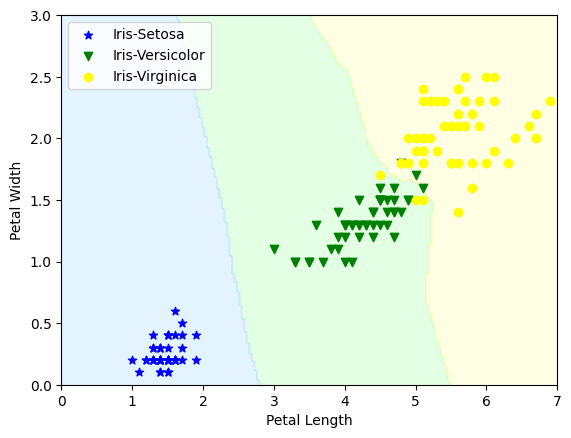

In [2]:
# pylint: disable=too-many-lines
"""Beginning of KNN code examples."""

from typing import cast, Dict
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

iris = cast(Dict, datasets.load_iris())
k = 5
X = iris["data"][:, 2:]
y = iris["target"]

# Euclidean distance
def calc_dist_euclidean(point1, point2):
    """Calculates the Euclidean distance between two given points."""
    current_sum = 0
    for coord in range(X.shape[1]):
        current_sum += (point1[coord] - point2[coord]) ** 2
    return current_sum ** ( 1 / 2 )

def predict_knn(x_train, y_train, point, k_neigh):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    dists = []
    # Get the distance of the point to every other
    # point in the training set (we considered the
    # whole dataset for demonstration purposes)
    for idx, train_point in enumerate(x_train):
        ed = calc_dist_euclidean(point, train_point)
        dists.append((ed, y_train[idx]))

    # Sort ascending
    dists.sort(key=lambda tup: tup[0])
    # Get the K closest points
    votes = dists[:k_neigh]
    # Count the total number of votes per class in
    # these K points
    total_votes = np.zeros(len(np.unique(y_train)))
    for vote in votes:
        total_votes[vote[1]] += 1
    # Prediction is the class with the largest amount
    # of votes (in a tie scenario, picks the one with
    # lowest index)
    return int(np.argmax(total_votes))

x_min, x_max = 0, 7
y_min, y_max = 0, 3

# Creates a dataset with every point in the plot, to
# show the predicted class in each set of coordinates
# and plots it
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample in range(data_points.shape[0]):
    predictions[sample] = predict_knn(x_train=X,
                                      y_train=y,
                                      point=data_points[sample, :],
                                      k_neigh=k)

predictions = predictions.reshape(xx.shape)

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend(loc=2)
plt.show()


The same code implemented using `scikit-learn` becomes much less verbose, while getting the same results, as seen below:

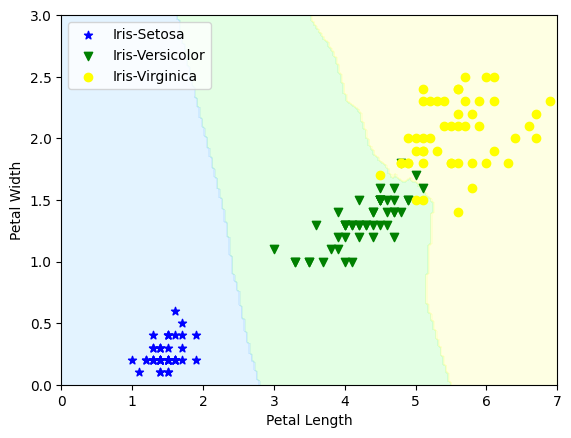

In [15]:
from typing import cast, Dict
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

iris = cast(Dict, datasets.load_iris())
k = 5
X = iris["data"][:, 2:]
y = iris["target"]
knn_model = KNeighborsClassifier(n_neighbors=k).fit(np.array(X), np.array(y))

x_min, x_max = 0, 7
y_min, y_max = 0, 3

# Creates a dataset with every point in the plot, to
# show the predicted class in each set of coordinates
# and plots it
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample in range(data_points.shape[0]):
    predictions[sample] = knn_model.predict(np.array([data_points[sample, :]]))[0]

predictions = predictions.reshape(xx.shape)

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend(loc=2)
plt.show()


In the interactive code below, you can choose a set of coordinates (which will appear in the color pink and with the marker of the predicted class) and its corresponding K closest points will appear as red!

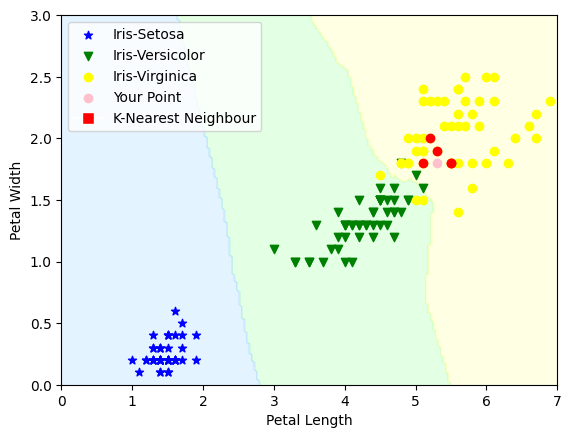

In [16]:
from typing import cast, Dict
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

your_point = [5.3, 1.8] # your point with coordinates [x,y]

iris = cast(Dict, datasets.load_iris())
X = iris["data"][:, 2:]
y = iris["target"]

k = 5

def calc_dist_euclid_2(point1, point2):
    """Calculates the Euclidean distance between
    two given points."""
    current_sum = 0
    for coord in range(X.shape[1]):
        current_sum += (point1[coord] - point2[coord]) ** 2
    return current_sum ** ( 1 / 2 )

def predict_knn_2(x_train, y_train, point, k_neigh):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    dists = []
    for idx, train_point in enumerate(x_train):
        dist = calc_dist_euclid_2(point, train_point)
        dists.append((dist, y_train[idx], train_point))

    dists.sort(key=lambda tup: tup[0])
    votes = dists[:k_neigh]
    total_votes = np.zeros(len(np.unique(y_train)))
    k_neighbours_list = []
    for vote in votes:
        total_votes[vote[1]] += 1
        k_neighbours_list.append((vote[2], vote[1]))
    return np.argmax(total_votes), k_neighbours_list

x_min, x_max = 0, 7
y_min, y_max = 0, 3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample in range(data_points.shape[0]):
    predictions[sample], _ = predict_knn_2(x_train=X,
                                           y_train=y,
                                           point=data_points[sample, :],
                                           k_neigh=k)

predictions = predictions.reshape(xx.shape)

your_point_class = int(predict_knn_2(X, y, point=your_point, k_neigh=k)[0])
k_neighbours = predict_knn_2(X, y, point=your_point, k_neigh=k)[1]

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

plt.scatter(your_point[0],
            your_point[1],
            marker=label_to_marker[your_point_class],
            c="pink",
            label="Your Point")

for neighbour_idx in range(k):
    marker = label_to_marker[k_neighbours[neighbour_idx][1]]
    plt.scatter(
        k_neighbours[neighbour_idx][0][0],
        k_neighbours[neighbour_idx][0][1],
        marker=marker,
        c="red"
    )

knn_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='red',
    markersize=8,
    label='K-Nearest Neighbour'
)
handles, labels = plt.gca().get_legend_handles_labels()

handles.append(knn_legend)
labels.append("K-Nearest Neighbour")

plt.legend(handles, labels, loc=2)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()


### Distances Impact <a id="distances-impact"></a>

In this example, we hand-coded most commonly used distance to show you a quick draft on the decision boundaries imposed by this algorithm on our given dataset. But, as you could have noticed by exploring the [distances notebook](./metrics/distances.ipynb), there are multiple distance metrics that can be used in the KNN algorithm and each of these provides different classification boundaries. Below, some distance metrics were selected and plotted to show you the impact that the metric selection has.

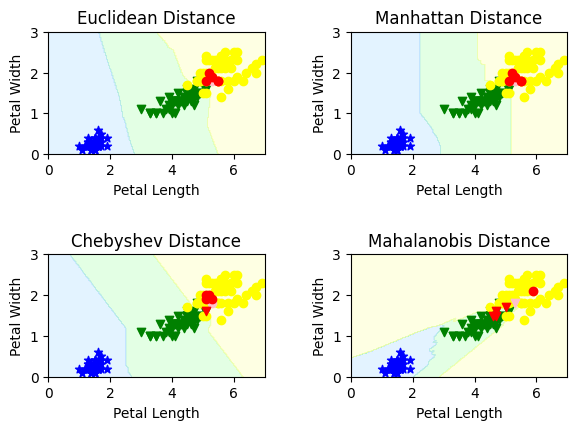

In [ ]:
from typing import cast, Dict
from sklearn import datasets
from sklearn.metrics import DistanceMetric
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from math import ceil

your_point = [5.3, 1.8] # your point with coordinates [x,y]

iris = cast(Dict, datasets.load_iris())
X = iris["data"][:, 2:]
y = iris["target"]

k = 5

distances = {
    "euclidean": DistanceMetric.get_metric('euclidean'),
    "manhattan": DistanceMetric.get_metric('manhattan'),
    "chebyshev": DistanceMetric.get_metric('chebyshev'),
    "mahalanobis": DistanceMetric
}

def get_dist(dist_name, x: np.ndarray | None) -> DistanceMetric:
    """Gets the corresponding DistanceMetric object for a given
    distance name."""
    if dist_name == 'mahalanobis' and x is not None:
        # rowvar=False indicates that the variables are represented in the
        # columns rather than the rows
        return DistanceMetric.get_metric('mahalanobis', V=np.cov(x, rowvar=False))
    return distances[dist_name]

def calc_dist(dist_name, point1, point2, x: None):
    """Calculates the selected distance between two given points.
    In case the calculated distance is Mahalanobis, requires the
    `x` matrix."""
    dist_fun = get_dist(dist_name, x)
    dist_scalar = dist_fun.pairwise(np.array([point1]),
                                    np.array([point2]))
    return dist_scalar

def predict_knn_3(x_train, y_train, point, dist_name, k_neigh):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    dists = []
    for idx, train_point in enumerate(x_train):
        dist = calc_dist(dist_name, point, train_point, x_train)
        dists.append((dist, y_train[idx], train_point))

    dists.sort(key=lambda tup: tup[0])
    votes = dists[:k_neigh]
    total_votes = np.zeros(len(np.unique(y_train)))
    k_neighbours_md = []
    for vote in votes:
        total_votes[vote[1]] += 1
        k_neighbours_md.append((vote[2], vote[1]))
    return np.argmax(total_votes), k_neighbours_md

x_min, x_max = 0, 7
y_min, y_max = 0, 3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

rows = 2
cols = ceil(len(distances.keys()) / 2)
fig, axes = plt.subplots(rows, cols)
axes = axes.flatten()

for index, distance_name in enumerate(distances):
    predictions = np.zeros(data_points.shape[0])
    for sample in range(data_points.shape[0]):
        predictions[sample], _ = predict_knn_3(x_train=X,
                                               y_train=y,
                                               point=data_points[sample, :],
                                               dist_name=distance_name,
                                               k_neigh=k)

    predictions = predictions.reshape(xx.shape)

    your_point_class = int(predict_knn_3(X,
                                         y,
                                         point=your_point,
                                         dist_name=distance_name,
                                         k_neigh=k)[0])
    k_neighbours = predict_knn_3(X,
                                 y,
                                 point=your_point,
                                 dist_name=distance_name,
                                 k_neigh=k)[1]

    X_setosa = X[y==0]
    X_versicolor = X[y==1]
    X_virginica = X[y==2]

    cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

    axes[index].axis((0.,7., 0.,3.))
    axes[index].contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
    axes[index].scatter(X_setosa[:,0],
                X_setosa[:,1],
                marker="*",
                c="blue", label="Iris-Setosa")
    axes[index].scatter(X_versicolor[:,0],
                X_versicolor[:,1],
                marker="v",
                c="green",
                label="Iris-Versicolor")
    axes[index].scatter(X_virginica[:,0],
                X_virginica[:,1],
                marker="o",
                c="yellow",
                label="Iris-Virginica")

    label_to_marker = {
        0: "*",
        1: "v",
        2: "o",
    }

    axes[index].scatter(your_point[0],
                your_point[1],
                marker=label_to_marker[your_point_class],
                c="pink",
                label="Your Point")

    for neighbour_idx in range(k):
        marker = label_to_marker[k_neighbours[neighbour_idx][1]]
        axes[index].scatter(
            k_neighbours[neighbour_idx][0][0],
            k_neighbours[neighbour_idx][0][1],
            marker=marker,
            c="red"
        )

    axes[index].set_xlabel("Petal Length")
    axes[index].set_ylabel("Petal Width")

    axes[index].set_title(f"{distance_name.capitalize()} Distance")

plt.tight_layout(pad=2.5)
plt.show()


The multiple graphics generated above are illustrative of the different decision boundaries created when varying the distance metric. The boundaries both in Manhattan and Chebyshev can be described through linear equations, without much of a curvature and rather incremental steps. This trend becomes easier to spot in the points further away from the features data points. It is easy to develop some intuition in these distances, as well as in the Euclidean distance, as the points that appear visually closer tend to be the closest neighbours. However, the Mahalanobis distance shows some stranger decision boundaries that are hard to visualize without plotting it. In this distance, it is possible to see in the graphic that even though the yellow points are the furthest (considering Euclidean distance) from those that have a petal length smaller than 2, these are the ones that are closer in the Mahalanobis distance. This happens because of the larger variance seen in both variables of the yellow data points. To develop some intuition, see this as the probability of a point in the plot belonging to a specific class: if a point appears further away from the data points, then it most likely belongs to the class with highest variance. Therefore, it is also safe to extend our thought to the fact that the closest point from class A to any point P, in the Mahalanobis distance, is always the point closest to the mean point of that class A.

To make a prediction, we calculated the distance of a point to all other points in the dataset. As mentioned, this becomes a hassle when the number of points in the dataset or the number of predictions to be made increases. To mitigate this issue, two different algorithms are used to avoid computing the distance total points in the dataset: Ball Tree and KD Tree. Each of those algorithms will be explored below, as an exercise to develop intuition regarding their use. However, in practice, the decision of which algorithm is abstracted from the user and handled by the called API (e.g. `scikit-learn`). In both algorithms, we are building a decision tree that will allow the nearest neighbours faster, utilizing binary tree search principles. As the algorithm switches from brute force to a tree-based algorithm, it stops being classified as lazy: it now learns patterns in the training data that later applies to new data. Because of this, the KNN algorithm object implemented in `scikit-learn` has a method called `.fit()`, despite at first glance looking redundant.

## Ball Tree <a id="ball-tree"></a>

A ball tree is a binary tree in which every node defines a D-dimensional ball containing a subset of points to be searched. Each node splits the dataset in two disjoint sets (balls). The balls may still intersect, but one point is always attributed to a single ball in a node. Each node is represented by the smallest ball that contains all data points in its subtree. Below, you will find a demonstration on how the Ball Tree is constructed.

In [3]:
# Loading data
from typing import cast, Dict
from sklearn.datasets import load_iris

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:]
y = iris['target']

random_state = 8


The first step in building a ball tree is randomly selecting a point from the dataset (shown in red in the resulting graphic):

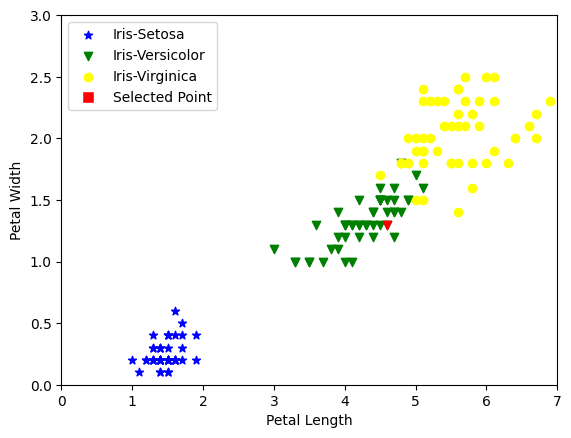

In [4]:
from random import choice, seed
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

seed(random_state)
initial_random_point = choice(X)
initial_random_point_class = choice(y)


x_min, x_max = 0, 7
y_min, y_max = 0, 3


label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}


X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.scatter(initial_random_point[0],
            initial_random_point[1],
            marker=label_to_marker[initial_random_point_class],
            c="red")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

knn_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='red',
    markersize=8,
    label='Random Point'
)
handles, labels = plt.gca().get_legend_handles_labels()

handles.append(knn_legend)
labels.append("Selected Point")

plt.legend(handles, labels, loc=2)

plt.show()


After selecting a random point, the brute-force algorithm is applied to find the point that stands the furthest away from the random point. Similarly to brute-force, any appropriate distance algorithm may be selected. Here, for simplicity purposes, the Euclidean distance was selected. 

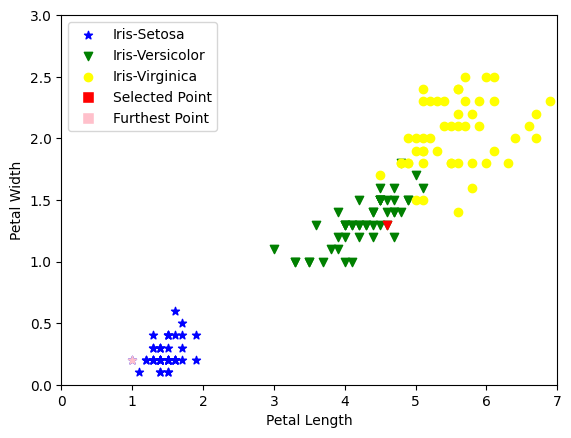

In [5]:
def euclidean_dist(point1, point2):
    """Calculates the Euclidean distance between two points"""
    dist = 0
    for idx, _ in enumerate(point1):
        coord_diff = point1[idx] - point2[idx]
        dist += coord_diff ** 2
    return dist ** (1 / 2)

distances = []
for i, train_p in enumerate(X):
    distance = euclidean_dist(initial_random_point, train_p)
    distances.append((distance, train_p, y[i]))

distances.sort(key=lambda tup: tup[0], reverse=True)
furthest_point = distances[0][1]
furthest_point_class = distances[0][2]

x_min, x_max = 0, 7
y_min, y_max = 0, 3


label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}


X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.scatter(furthest_point[0],
            furthest_point[1],
            marker=label_to_marker[furthest_point_class],
            c="pink")
plt.scatter(initial_random_point[0],
            initial_random_point[1],
            marker=label_to_marker[initial_random_point_class],
            c="red")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

random_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='red',
    markersize=8,
    label='Random Point'
)

furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='pink',
    markersize=8,
    label='Furthest Point'
)
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(random_point_legend)
handles.append(furthest_point_legend)
labels.append("Selected Point")
labels.append("Furthest Point")

plt.legend(handles, labels, loc=2)

plt.show()


Parting from the calculated furthest point (pink in the image above) the furthest point relative to it is found using brute-force again, as follows: 

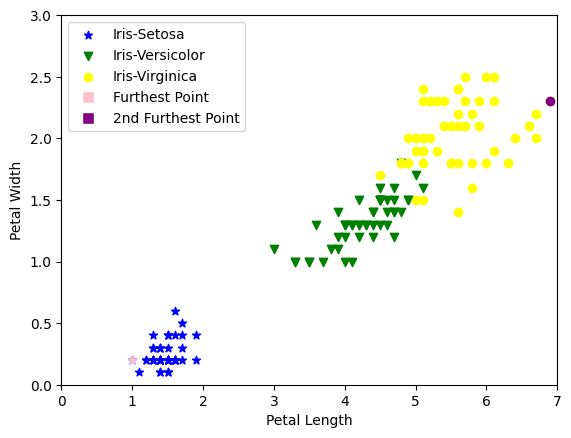

In [6]:
def euclidean_dist_2(point1, point2):
    """Calculates the Euclidean distance between two points"""
    dist = 0
    for idx, _ in enumerate(point1):
        coord_diff = point1[idx] - point2[idx]
        dist += coord_diff ** 2
    return dist ** (1 / 2)


distances = []
for index, t_point in enumerate(X):
    distance = euclidean_dist(furthest_point, t_point)
    distances.append((distance, t_point, y[index]))

distances.sort(key=lambda tup: tup[0], reverse=True)
second_furthest_point = distances[0][1]
second_furthest_point_class = distances[0][2]
distance_between_points = distances[0][0]

x_min, x_max = 0, 7
y_min, y_max = 0, 3


label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}


X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.scatter(furthest_point[0],
            furthest_point[1],
            marker=label_to_marker[furthest_point_class],
            c="pink")
plt.scatter(second_furthest_point[0],
            second_furthest_point[1],
            marker=label_to_marker[second_furthest_point_class],
            c="purple")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")


furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='pink',
    markersize=8,
    label='Furthest Point'
)

second_furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='purple',
    markersize=8,
    label='2nd Furthest Point'
)
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(furthest_point_legend)
handles.append(second_furthest_point_legend)
labels.append("Furthest Point")
labels.append("2nd Furthest Point")

plt.legend(handles, labels, loc=2)

plt.show()


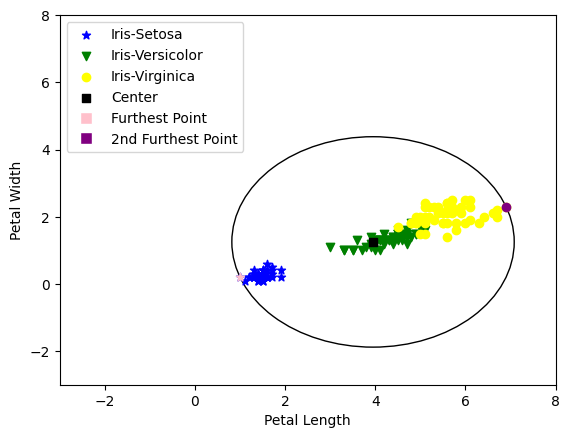

O Hyper-Sphere Center: (3.95, 1.25)
O Hyper-Sphere Radius: 3.13


In [7]:
import numpy as np
from matplotlib.patches import Circle

furthest_point = np.array(furthest_point)
second_furthest_point = np.array(second_furthest_point)

center_point = (furthest_point + second_furthest_point) / 2
radius = distance_between_points / 2

circle = Circle(tuple(center_point), radius, fill=False, color='black')

x_min, x_max = 0, 7
y_min, y_max = 0, 7


label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}


X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

fig, axes = plt.subplots()

axes.add_artist(circle)

plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.scatter(furthest_point[0],
            furthest_point[1],
            marker=label_to_marker[furthest_point_class],
            c="pink")
plt.scatter(second_furthest_point[0],
            second_furthest_point[1],
            marker=label_to_marker[second_furthest_point_class],
            c="purple")
plt.scatter(center_point[0], center_point[1], marker="s", c="black", label="Center")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")


furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='pink',
    markersize=8,
    label='Furthest Point'
)

second_furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='purple',
    markersize=8,
    label='2nd Furthest Point'
)

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(furthest_point_legend)
handles.append(second_furthest_point_legend)
labels.append("Furthest Point")
labels.append("2nd Furthest Point")

plt.legend(handles, labels, loc=2)

plt.show()

print(f"O Hyper-Sphere Center: ({center_point[0]}, {center_point[1]})")
print(f"O Hyper-Sphere Radius: {radius:.2f}")


This is our first hyper-sphere, O, and it contains all the data points from our dataset. In this case, because our features are two-dimensional, this hyper-sphere is a circle, but, as the feature space increases in dimensions, the ball has the same dimensions as the features. The direction that goes from one of the furthest points to another is considered the direction of highest variability. Now, we project every other data point into this line and split it in two sections, with the goal of equally distributing the number of points. 

Consider the current dataset as $X \in \mathbb{R}^{N}$, where $N$ is the number of dimensions in our dataset (in this case, since there are only two features, $N=2$). To project our dataset to a single line, we need a direction vector $w$ so that $w \in \mathbb{R}^{N}$. The projection $z$ is obtained through $z = w^{T}x$ and it is posisble to define the direction vector $u$ of the projection line as $u = b - a$ where $a$ and $b$ are the two opposite points introduced earlier. A projection of a data point into a line means that the resulting point is the closest point belonging to this line. Considering the equation that defines the line between $a$ and $b$ as $l(t) = a + ut$, we get that the euclidean distance between any random point ($d(x)$) to this line is:

$$
d(x) = (x - (a + ut))^2
$$

We can elaborate this distance as:

$$
\begin{aligned}
    d(x) &= (x - a - ut)^{T}(x - a - ut) \\
    \Leftrightarrow d(x) &= (x - a - ut)^{T}(x - a - ut) \\
    \Leftrightarrow d(x) &= (x - a)^{T}(x - a) - 2 (x - a)(ut) + (ut)^{T}(ut) \\
\end{aligned}
$$

Because the goal is to find the minimal distance $d(x)$, by comparing the derivative of the function $d$ in respect to $t$ to 0, it is possible to determine the minimal distance of any point $x$ with respect to $t$:

$$
\begin{aligned}
    & \frac{\partial d(x)}{\partial t} d(x) = 0 \\
    \Leftrightarrow & - 2u (x - a) + 2u^{T}ut = 0 \\
    \Leftrightarrow & 2u^{T}ut = 2u (x - a) \\
    \Leftrightarrow & t = \frac{2u (x - a)}{2u^{T}u} \\
    \Leftrightarrow & t = \frac{u (x - a)}{u^{T}u} \\
\end{aligned}
$$

Replacing $u$ by $b - a$, we get:

$$
\begin{aligned}
    t &= \frac{(b - a) (x - a)}{(b - a)^{T} (b - a)} \\
    \Leftrightarrow t &= \frac{(b - a) (x - a)}{||b - a||}
\end{aligned}
$$

Where:

$$
||b - a|| = \sqrt{\sum_{n}^{N} \left( (b_{n} - a_{n})^{2} \right)} 
$$

If you prefer the $u$ notation, it is common to convert it to the unit vector, by performing:

$$
\hat{u} = u / ||u|| \\
\Leftrightarrow \hat{u} = (b - a) / ||b - a||
$$

And the projection equation can be simplified to:
$$
t = \hat{u} (x - a)
$$

$t$ will be the 1D variable that corresponds to the projection of the data points on the line between the two far points. Then, the data is split on the median, and the process of selecting the two furthest points begins again.

In [8]:
def calculate_norm(arr: np.ndarray):
    """Calculates the norm of a given vector"""
    return np.sqrt(np.sum(arr ** 2))

a = furthest_point
b = second_furthest_point

u = a - b
u_norm = calculate_norm(u)
unit_vector = u / u_norm

data_points_projection = unit_vector @ (X - a).T
points_projection_pair = np.c_[X, data_points_projection]

first_split = points_projection_pair[
                data_points_projection < np.median(data_points_projection)
            ]
second_split = points_projection_pair[
                data_points_projection >= np.median(data_points_projection)
            ]

splits = [first_split, second_split]

trees = {0: [[center_point, float(round(radius, 2))]]}

print(trees)


{0: [[array([3.95, 1.25]), 3.13]]}


After dividing the datapoints by the median, we repeat the same process for every hypersphere until the number of points inside of it is smaller than the number of leaves allowed. The number of leaves allowed is an hyperparameter and we tune it based on our needs, considering the equilibrium between memory and calculation speed. The higher the number of leaves, the higher the number of calculations to be performed during inference using brute-force. The lower the number of leaves, the larger the memory required to store the tree, as it will have more nodes. `scikit-learn` default value for this parameter is 40. To make this more visually interesting, the number of leaves will be reduced in order to plot more hyperspheres.

In [9]:
n_leaves = 20

def get_norm(arr: np.ndarray):
    """Calculates the norm of a given vector"""
    return np.sqrt(np.sum(arr ** 2))

def euclidean_dist_fun(point1, point2):
    """Calculates the Euclidean distance between two
    given points"""
    sum_diffs = 0
    for dim, _ in enumerate(point1):
        sum_diffs += (point1[dim] - point2[dim]) ** 2

    return sum_diffs ** (1 / 2)


all_trees_leaves_pass = False
depth = 1
splits = [split[:,:2] for split in splits]


new_splits = []
while not all_trees_leaves_pass:
    n_leaves_trees = []
    trees[depth] = []
    new_splits = []

    for split in splits:
        random_point = choice(split)

        max_distance = 0
        furthest_point = random_point
        for pt in split:
            distance = euclidean_dist_fun(random_point, pt)
            if distance > max_distance:
                max_distance = distance
                furthest_point = pt

        diameter = 0
        second_furthest_point = random_point
        for pt in split:
            distance = euclidean_dist_fun(furthest_point, pt)
            if distance > diameter:
                diameter = distance
                second_furthest_point = pt

        center = (np.array(furthest_point) + np.array(second_furthest_point)) / 2
        radius = diameter / 2

        radius = 0
        for pt in split:
            distance_center = euclidean_dist_fun(pt, center)
            if distance_center > radius:
                radius = distance_center

        trees[depth].append([center, round(radius, 2)])

        if len(split) >= n_leaves:
            u = furthest_point - second_furthest_point
            u_norm = get_norm(u)
            unit_vector = u / u_norm

            data_points_projection = unit_vector @ (split - furthest_point).T

            first_split = split[
                    data_points_projection < np.median(data_points_projection)
                ]
            second_split = split[
                    data_points_projection >= np.median(data_points_projection)
                ]

            if len(first_split) > 0:
                new_splits.append(first_split)
                n_leaves_trees.append(len(first_split))
            if len(second_split) > 0:
                new_splits.append(second_split)
                n_leaves_trees.append(len(second_split))

        else:
            new_splits.append(split)
            n_leaves_trees.append(len(split))

    all_trees_leaves_pass = all(n < n_leaves for n in n_leaves_trees) \
                            and not \
                            any(len(s) >= n_leaves for s in new_splits)

    splits = new_splits
    depth += 1


############################################################
Hyper-Sphere Tree Depth: 0
Hyper-Sphere Node: 0
Hyper-Sphere Center: (3.95, 1.25)
Hyper-Sphere Radius: 3.13


############################################################
Hyper-Sphere Tree Depth: 1
Hyper-Sphere Node: 0
Hyper-Sphere Center: (5.65, 1.75)
Hyper-Sphere Radius: 1.37


############################################################
Hyper-Sphere Tree Depth: 1
Hyper-Sphere Node: 1
Hyper-Sphere Center: (2.65, 0.75)
Hyper-Sphere Radius: 1.74


############################################################
Hyper-Sphere Tree Depth: 2
Hyper-Sphere Node: 0
Hyper-Sphere Center: (4.70, 1.60)
Hyper-Sphere Radius: 0.50


############################################################
Hyper-Sphere Tree Depth: 2
Hyper-Sphere Node: 1
Hyper-Sphere Center: (6.00, 2.10)
Hyper-Sphere Radius: 0.95


############################################################
Hyper-Sphere Tree Depth: 2
Hyper-Sphere Node: 2
Hyper-Sphere Center: (1.25, 0.30)
Hy

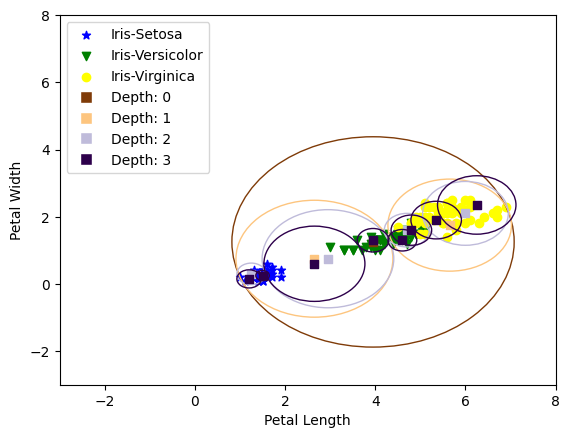

In [10]:
from matplotlib import colormaps
from matplotlib.patches import Circle

cmap = colormaps['PuOr']
vmin = min(trees.keys())
vmax = max(trees.keys())

def norm(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)


x_min, x_max = 0, 7
y_min, y_max = 0, 7

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

fig, axes = plt.subplots()


plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

for depth, nodes in trees.items():
    color = cmap(norm(depth, vmin, vmax))
    for node_id, node in enumerate(nodes):
        center_point, radius = node
        circle = Circle(tuple(center_point), radius, fill=False, color=color)
        axes.add_artist(circle)
        plt.scatter(center_point[0], center_point[1], marker="s", color=color, label="Center")

        print("#" * 60)
        print(f"Hyper-Sphere Tree Depth: {depth}")
        print(f"Hyper-Sphere Node: {node_id}")
        print(f"Hyper-Sphere Center: ({center_point[0]:.2f}, {center_point[1]:.2f})")
        print(f"Hyper-Sphere Radius: {radius:.2f}")
        print("\n")

    depth_legend = Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=f'Depth: {depth}'
    )
    handles.append(depth_legend)
    labels.append(f"Depth: {depth}")

plt.legend(handles, labels, loc=2)
plt.show()


The fully constructed optimized algorithm, that goes from data loading to plotting, would look something like this, using NumPy. The results differ from the previous cell because of the change in random point selection.

############################################################
Hyper-Sphere ID: 00
Hyper-Sphere Depth: 0
Hyper-Sphere Node: 0
Hyper-Sphere Center: (3.95, 1.25)
Hyper-Sphere Radius: 3.13
Hyper-Sphere Children: ['10', '11']


############################################################
Hyper-Sphere ID: 10
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 0
Hyper-Sphere Center: (5.65, 1.75)
Hyper-Sphere Radius: 1.37
Hyper-Sphere Children: ['20', '21']


############################################################
Hyper-Sphere ID: 11
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 1
Hyper-Sphere Center: (2.65, 0.75)
Hyper-Sphere Radius: 1.74
Hyper-Sphere Children: ['22', '23']


############################################################
Hyper-Sphere ID: 20
Hyper-Sphere Depth: 2
Hyper-Sphere Node: 0
Hyper-Sphere Center: (4.70, 1.60)
Hyper-Sphere Radius: 0.50
Hyper-Sphere Children: ['30', '31']


############################################################
Hyper-Sphere ID: 21
Hyper-Sphere Depth: 2
Hyper-Sph

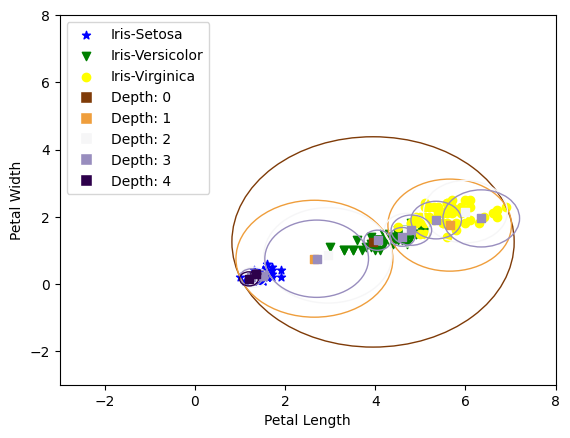

In [11]:
import numpy as np
from typing import cast, Dict
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

random_state = 8
n_leaves = 20

rng = np.random.default_rng(random_state)

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(np.float32)
y = iris['target']

index_col = np.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = np.hstack((index_col, X))

def norm_(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)

all_leaves_small = False
depth = 0
splits: list[np.ndarray] = [X]
trees: dict[int, list] = {}
new_splits: list[np.ndarray] = []

while True:
    trees[depth] = []
    new_splits = []
    depth_node_counter = 0

    for split in splits:
        split_points = split[:, 1:]

        split_points = np.atleast_2d(split_points)
        pivot = split_points[rng.integers(len(split_points))]

        diff1 = split_points - pivot
        dist1 = np.einsum('ij,ij->i', diff1, diff1)
        furthest = split_points[np.argmax(dist1)]

        diff2 = split_points - furthest
        dist2 = np.einsum('ij,ij->i', diff2, diff2)
        idx2 = np.argmax(dist2)
        opposite = split_points[idx2]
        center = (furthest + opposite) * 0.5

        diff_center = split_points - center
        diff_center = np.einsum('ij,ij->i', diff_center, diff_center)
        radius = float(np.sqrt(np.max(diff_center)))

        split_indexes = None

        if len(split) > n_leaves:
            u = furthest - opposite
            unit_vector = u / np.linalg.norm(u)

            projections = (split_points - furthest) @ unit_vector
            median_val = np.median(projections)
            mask = projections <= median_val
            first_split = split[mask]
            second_split = split[~mask]

            if len(first_split) > 0:
                new_splits.append(first_split)
            if len(second_split) > 0:
                new_splits.append(second_split)

            if len(first_split) > 0 and len(second_split) > 0:
                childs = [
                    str(depth + 1) + str(depth_node_counter),
                    str(depth + 1) + str(depth_node_counter + 1)
                ]
                depth_node_counter += 2
            else:
                childs = None
                split_indexes = split[:, 0]
        else:
            childs = None
            split_indexes = split[:, 0]

        trees[depth].append([center, round(radius, 2), childs, split_indexes])

    if not new_splits:
        break

    if all(len(s) < n_leaves for s in new_splits):
        splits = new_splits
        depth += 1
        continue

    splits = new_splits
    depth += 1


cmap = colormaps['PuOr']
vmin = min(trees.keys())
vmax = max(trees.keys())

x_min, x_max = 0, 7
y_min, y_max = 0, 7

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

X_points = X[:, 1:]

X_setosa = X_points[y==0]
X_versicolor = X_points[y==1]
X_virginica = X_points[y==2]

fig, axes = plt.subplots()


plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

for depth, nodes in trees.items():
    color = cmap(norm_(depth, vmin, vmax))
    for node_id, node in enumerate(nodes):
        center_point, radius, children, split_indexes = node
        circle = Circle(tuple(center_point), radius, fill=False, color=color)
        axes.add_artist(circle)
        plt.scatter(center_point[0], center_point[1], marker="s", color=color, label="Center")

        print("#" * 60)
        print(f"Hyper-Sphere ID: {depth}{node_id}")
        print(f"Hyper-Sphere Depth: {depth}")
        print(f"Hyper-Sphere Node: {node_id}")
        print(f"Hyper-Sphere Center: ({center_point[0]:.2f}, {center_point[1]:.2f})")
        print(f"Hyper-Sphere Radius: {radius:.2f}")
        if children:
            print(f"Hyper-Sphere Children: {children}")
        if split_indexes is not None:
            print(f"Hyper-Sphere Number of Points: {len(split_indexes)}")
        print("\n")

    depth_legend = Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=f'Depth: {depth}'
    )
    handles.append(depth_legend)
    labels.append(f"Depth: {depth}")

plt.legend(handles, labels, loc=2)
plt.show()


Now, doing the same thing with JAX instead of NumPy:

############################################################
Hyper-Sphere ID: 00
Hyper-Sphere Depth: 0
Hyper-Sphere Node: 0
Hyper-Sphere Center: (3.95, 1.25)
Hyper-Sphere Radius: 3.13
Hyper-Sphere Children: ['10', '11']


############################################################
Hyper-Sphere ID: 10
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 0
Hyper-Sphere Center: (5.65, 1.75)
Hyper-Sphere Radius: 1.37
Hyper-Sphere Children: ['20', '21']


############################################################
Hyper-Sphere ID: 11
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 1
Hyper-Sphere Center: (2.65, 0.75)
Hyper-Sphere Radius: 1.74
Hyper-Sphere Children: ['22', '23']


############################################################
Hyper-Sphere ID: 20
Hyper-Sphere Depth: 2
Hyper-Sphere Node: 0
Hyper-Sphere Center: (4.75, 1.55)
Hyper-Sphere Radius: 0.51
Hyper-Sphere Children: ['30', '31']


############################################################
Hyper-Sphere ID: 21
Hyper-Sphere Depth: 2
Hyper-Sph

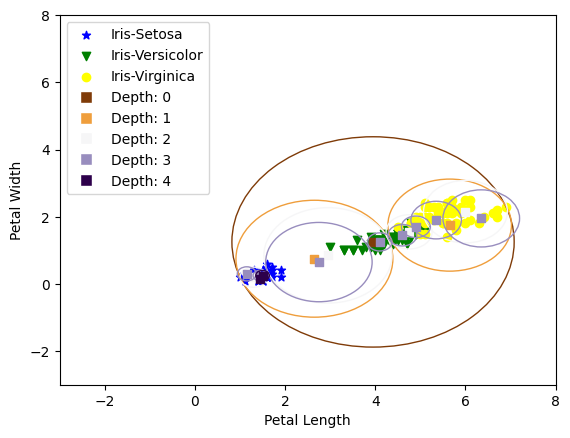

In [12]:
from jax.random import PRNGKey, randint, split as jax_split
import jax.numpy as jnp
from typing import cast, Dict
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

random_state = 8
n_leaves = 20

key = PRNGKey(random_state)

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(jnp.float32)
y = iris['target']

index_col = jnp.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = jnp.hstack((index_col, X))

def normalize(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)

all_leaves_small = False
depth = 0
splits: list[jnp.ndarray] = [X]
jax_trees: dict[int, list] = {}
new_splits: list[jnp.ndarray] = []

while True:
    jax_trees[depth] = []
    new_splits = []
    depth_node_counter = 0

    for split in splits:
        split_indexes = None
        childs = None
        split_points = split[:, 1:]
        split_points = jnp.atleast_2d(split_points)

        key, subkey = jax_split(key)
        pivot = split_points[randint(subkey, (), 0, len(split_points))]

        diff1 = split_points - pivot
        dist1 = jnp.einsum('ij,ij->i', diff1, diff1)
        furthest = split_points[jnp.argmax(dist1)]

        diff2 = split_points - furthest
        dist2 = jnp.einsum('ij,ij->i', diff2, diff2)
        idx2 = jnp.argmax(dist2)
        opposite = split_points[idx2]
        center = (furthest + opposite) * 0.5

        diff_center = split_points - center
        diff_center = jnp.einsum('ij,ij->i', diff_center, diff_center)
        radius = float(jnp.sqrt(jnp.max(diff_center)))

        if len(split) > n_leaves:
            u = furthest - opposite
            unit_vector = u / jnp.linalg.norm(u)

            projections = (split_points - furthest) @ unit_vector
            median_val = jnp.median(projections)
            mask = projections <= median_val
            first_split = split[mask]
            second_split = split[~mask]

            if len(first_split) > 0:
                new_splits.append(first_split)
            if len(second_split) > 0:
                new_splits.append(second_split)

            if len(first_split) > 0 and len(second_split) > 0:
                childs = [
                    str(depth + 1) + str(depth_node_counter),
                    str(depth + 1) + str(depth_node_counter + 1)
                ]
                depth_node_counter += 2
            else:
                childs = None
                split_indexes = split[:, 0]
        else:
            childs = None
            split_indexes = split[:, 0]

        jax_trees[depth].append([center, round(radius, 2), childs, split_indexes])

    if not new_splits:
        break

    if all(len(s) < n_leaves for s in new_splits):
        splits = new_splits
        depth += 1
        continue

    splits = new_splits
    depth += 1

cmap = colormaps['PuOr']
vmin = min(jax_trees.keys())
vmax = max(jax_trees.keys())

x_min, x_max = 0, 7
y_min, y_max = 0, 7

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

X_points = X[:, 1:]

X_setosa = X_points[y==0]
X_versicolor = X_points[y==1]
X_virginica = X_points[y==2]

fig, axes = plt.subplots()


plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

for depth, nodes in jax_trees.items():
    color = cmap(normalize(depth, vmin, vmax))
    for node_id, node in enumerate(nodes):
        center_point, radius, children, split_indexes = node
        circle = Circle(tuple(center_point), radius, fill=False, color=color)
        axes.add_artist(circle)
        plt.scatter(center_point[0], center_point[1], marker="s", color=color, label="Center")

        print("#" * 60)
        print(f"Hyper-Sphere ID: {depth}{node_id}")
        print(f"Hyper-Sphere Depth: {depth}")
        print(f"Hyper-Sphere Node: {node_id}")
        print(f"Hyper-Sphere Center: ({center_point[0]:.2f}, {center_point[1]:.2f})")
        print(f"Hyper-Sphere Radius: {radius:.2f}")
        if children:
            print(f"Hyper-Sphere Children: {children}")
        if split_indexes is not None:
            print(f"Hyper-Sphere Number of Points: {len(split_indexes)}")
        print("\n")

    depth_legend = Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=f'Depth: {depth}'
    )
    handles.append(depth_legend)
    labels.append(f"Depth: {depth}")

plt.legend(handles, labels, loc=2)
plt.show()


After constructing the tree, the next step is using it to make predictions. The algorithm used for inference is called the branch-and-bound transversal. We start with the first node and, unless our tree only has one node (in that case, we just use brute-force), we immediatly pass on to the next set of balls. For each of these balls, we will calculate the best possible distance from the query point to the center of these hyper-balls as the `distance - radius`. Keep in mind that the same distance used in the construction of the ball tree must be used during inference, in this step. Because branch-and-bound is a depth first algorithm, we are going to proceed with the nodes that are more promising (the ones with smaller best possible distance) first, but both nodes are added to the queue we are iterating, as well as their respective distances to the query point, to avoid re-computations. This best possible distance can be negative when the query point is already inside the ball tree, but that is ok as we are just using this to compare between possible nodes. To be more precise in the sense of what defines the best possible distance, you can impose a condition and switch all negative distances by zero.

We repeat this process until we reach the leaves, always adding the new nodes (and their respective distances to the query point) as the next nodes to be searched, before in queue than those older, shallower, added prior. When the first leaves are reached, we brute-force and calculate the k-closest points to the query point. To make the further querying process easier, we keep this list ordered so that the last point is the furthest from the query point (this is a heap of the k-closest points). After this, we move on to the following node in queue and we check if its distance to the query point is smaller than the last point in heap. If it is, we iterate through all the points in this hyper-sphere via brute-force. If it is not, we just ignore this ball because we know that no point inside of this hyper-sphere will be on the k-closest points. This saves much compute because we do not need to compute the distance to all points in the dataset in order to find the k-closest points. We keep repeating this process until all nodes have been iterated and we use the heap to calculate what is the predicted class for the given data point.

In [13]:
import numpy as np
from typing import cast, Dict
from sklearn.datasets import load_iris

# Loading the same point we did previously
query_point = [5.3, 1.8]

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(np.float32)
y = iris['target']

index_col = np.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = np.hstack((index_col, X))

# Selecting a tree to work with.
# You can change to jax_trees, as well.
tree = trees
queue = [['00', None]]
k = 5

def get_euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two points"""
    return np.sqrt(np.sum((point1 - point2) ** 2, axis=0))

def get_k_neighbours(k_best, leaves, query, labels_match):
    """Updates the list of the K-closest points"""
    for idx, leave in enumerate(leaves):
        dist = get_euclidean_distance(query, leave)

        if dist < k_best[-1][1]:
            k_best[-1] = [leave, dist, labels_match[idx]]
            k_best.sort(key=lambda x: x[1])

    return k_best

def get_child_node_order(ball_tree, child_nodes, query):
    """Orders the two child nodes based on the best possible distance,
    in ascending order"""
    node_1_center = ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][0]
    node_1_radius = ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][1]
    node_2_center = ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][0]
    node_2_radius = ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][1]

    best_distance_to_node_1 = get_euclidean_distance(query, node_1_center) - node_1_radius
    best_distance_to_node_2 = get_euclidean_distance(query, node_2_center) - node_2_radius

    if best_distance_to_node_2 < best_distance_to_node_1:
        return [[child_nodes[1], best_distance_to_node_2],
                [child_nodes[0], best_distance_to_node_1]]
    return [[child_nodes[0], best_distance_to_node_1],
            [child_nodes[1], best_distance_to_node_2]]

k_best_list = [[np.array([0, 0]), float('inf')]] * k

while len(queue) > 0:
    node = tree[int(queue[0][0][0])][int(queue[0][0][1])]
    center = node[0]
    radius = node[1]

    if not queue[0][1] or int(queue[0][0][0]) == 0:
        queue[0][1] = get_euclidean_distance(center, query_point) - radius

    if queue[0][1] < k_best_list[-1][1]:
        if node[3] is None:
            child_nodes_ordered = get_child_node_order(tree, node[2], query_point)
            queue = [queue[0]] + child_nodes_ordered + queue[1:]
        else:
            leaves_to_check = X[np.array(node[3], dtype=int)][:, 1:]
            labels = y[np.array(node[3], dtype=int)]
            k_best_list = get_k_neighbours(k_best_list, leaves_to_check, query_point, labels)

    queue = queue[1:]

    if not queue:
        break

k_votes = [int(point[-1]) for point in k_best_list]
votes_counter = np.zeros(len(np.unique(y)))
for vote_ in k_votes:
    votes_counter[vote_] += 1
predicted_class = np.argmax(votes_counter)

print(f"Final Classification: {predicted_class}")


Final Classification: 2


The same inference strategy using JAX instead of NumPy:

In [14]:
import jax
import jax.numpy as jnp
import functools
from typing import cast, Dict
from sklearn.datasets import load_iris

# Loading the same point we did previously,
# but as a JAX array
query_point = jnp.array([5.3, 1.8])

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(jnp.float32)
y = iris['target']

index_col = jnp.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = jnp.hstack((index_col, X))

# Selecting a tree to work with.
# You can change to jax_trees, as well.
tree = jax_trees
queue = [['00', None]]
k = 5

@jax.jit
def get_jax_euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between
    two points using JAX functions"""
    return jnp.sqrt(jnp.sum((point1 - point2) ** 2))

@jax.jit
def get_best_distances(query, centers, radii):
    """Vectorized: compute best-possible distances to multiple nodes at once"""
    diffs = centers - query
    dists = jnp.sqrt(jnp.sum(diffs ** 2, axis=1))
    return dists - radii

@functools.partial(jax.jit, static_argnums=(6,))
def update_k_neighbours(k_best_distances, k_best_pts, k_best_labels_,
                        leaf_points, leaf_labels, query, k_neigh):
    """Updates the list of the K-closest points"""
    diffs = leaf_points - query
    dists = jnp.sqrt(jnp.sum(diffs ** 2, axis=1))

    all_dists = jnp.concatenate([k_best_distances, dists])
    all_points = jnp.concatenate([k_best_pts, leaf_points], axis=0)
    all_labels = jnp.concatenate([k_best_labels_, leaf_labels])

    top_k_idx = jnp.argsort(all_dists)[:k_neigh]

    return (all_dists[top_k_idx],
            all_points[top_k_idx],
            all_labels[top_k_idx])

def get_child_node_order_jax(ball_tree, child_nodes, query):
    """Orders the two child nodes based on the best possible distance,
    in ascending order"""
    node_centers = jnp.array([
        ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][0],
        ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][0]
    ])
    node_radii = jnp.array([
        ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][1],
        ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][1]
    ])

    best_distances_to_node = get_best_distances(query, node_centers, node_radii)

    order = jnp.argsort(best_distances_to_node)

    return [[child_nodes[order[0]], best_distances_to_node[order[0]]],
            [child_nodes[order[1]], best_distances_to_node[order[1]]]]

k_best_points = jnp.full((k, 2), jnp.inf)
k_best_dists  = jnp.full((k,), jnp.inf)
k_best_labels = jnp.full((k,), -1, dtype=jnp.int32)

X_points = jnp.array(X[:, 1:])
y_labels = jnp.array(y, dtype=jnp.int32)

while len(queue) > 0:
    node = tree[int(queue[0][0][0])][int(queue[0][0][1])]
    center = node[0]
    radius = node[1]

    if not queue[0][1] or int(queue[0][0][0]) == 0:
        queue[0][1] = get_jax_euclidean_distance(center, query_point) - radius

    if queue[0][1] < k_best_dists[-1]:
        if node[3] is None:
            child_nodes_ordered = get_child_node_order_jax(tree, node[2], query_point)
            queue = [queue[0]] + child_nodes_ordered + queue[1:]
        else:
            indexes = jnp.array(node[3], dtype=jnp.int32)
            k_best_dists, k_best_points, k_best_labels = update_k_neighbours(
                k_best_dists, k_best_points, k_best_labels,
                X_points[indexes], y_labels[indexes], query_point, k
            )

    queue = queue[1:]

    if not queue:
        break

k_votes = jnp.array(k_best_labels, dtype=jnp.int32)
votes_counter = jnp.bincount(k_votes, length=len(jnp.unique(y)))
predicted_class = jnp.argmax(votes_counter)

print(f"Final Classification: {predicted_class}")


Final Classification: 2


Now, validating our progresses by showing our predictions map for the NumPy Ball Tree.

############################################################
Hyper-Sphere ID: 00
Hyper-Sphere Depth: 0
Hyper-Sphere Node: 0
Hyper-Sphere Center: (3.95, 1.25)
Hyper-Sphere Radius: 3.13
Hyper-Sphere Children: ['10', '11']


############################################################
Hyper-Sphere ID: 10
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 0
Hyper-Sphere Center: (5.65, 1.75)
Hyper-Sphere Radius: 1.37
Hyper-Sphere Children: ['20', '21']


############################################################
Hyper-Sphere ID: 11
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 1
Hyper-Sphere Center: (2.65, 0.75)
Hyper-Sphere Radius: 1.74
Hyper-Sphere Children: ['22', '23']


############################################################
Hyper-Sphere ID: 20
Hyper-Sphere Depth: 2
Hyper-Sphere Node: 0
Hyper-Sphere Center: (4.70, 1.60)
Hyper-Sphere Radius: 0.50
Hyper-Sphere Children: ['30', '31']


############################################################
Hyper-Sphere ID: 21
Hyper-Sphere Depth: 2
Hyper-Sph

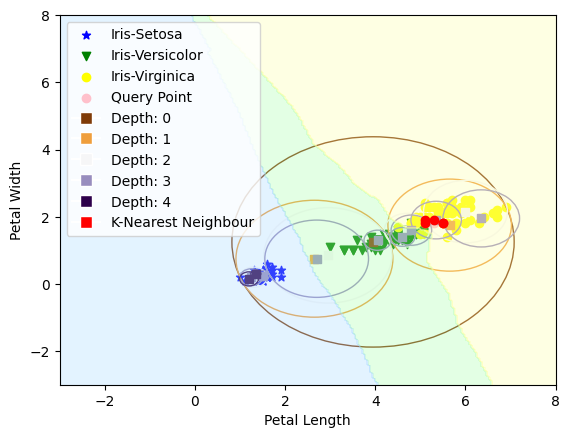

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

def normalize_(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)

cmap = colormaps['PuOr']
vmin = min(trees.keys())
vmax = max(trees.keys())

x_min, x_max = -3, 8
y_min, y_max = -3, 8

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])

query_point = [5.3, 1.8]

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(np.float32)
y = iris['target']

index_col = np.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = np.hstack((index_col, X))

X_setosa = X[:, 1:][y==0]
X_versicolor = X[:, 1:][y==1]
X_virginica = X[:, 1:][y==2]

k = 5

def get_euclidean_distance_(point1, point2):
    """Calculates the Euclidean distance between two points"""
    return np.sqrt(np.sum((point1 - point2) ** 2, axis=0))

def get_k_neighbours_(k_best, leaves, query, labels_match):
    """Updates the list of the K-closest points"""
    for idx, leave in enumerate(leaves):
        dist = get_euclidean_distance_(query, leave)

        if dist < k_best[-1][1]:
            k_best[-1] = [leave, dist, labels_match[idx]]
            k_best.sort(key=lambda x: x[1])

    return k_best

def get_child_node_order_(ball_tree, child_nodes, query):
    """Orders the two child nodes based on the best possible distance,
    in ascending order"""
    node_1_center = ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][0]
    node_1_radius = ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][1]
    node_2_center = ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][0]
    node_2_radius = ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][1]

    best_distance_to_node_1 = get_euclidean_distance_(query, node_1_center) - node_1_radius
    best_distance_to_node_2 = get_euclidean_distance_(query, node_2_center) - node_2_radius

    if best_distance_to_node_2 < best_distance_to_node_1:
        return [[child_nodes[1], best_distance_to_node_2],
                [child_nodes[0], best_distance_to_node_1]]
    return [[child_nodes[0], best_distance_to_node_1],
            [child_nodes[1], best_distance_to_node_2]]


def predict_ball_tree(ball_tree, single_query_point, k_neigh: int=5):
    """Infers the class of a given query point using a built Ball Tree
    for k neighbours"""
    ball_tree_queue = [['00', None]]
    k_best_list_ = [
        [np.array([0, 0]), float('inf'), -1]
        for _ in range(k_neigh)
    ]
    while len(ball_tree_queue) > 0:
        tree_node = ball_tree[int(ball_tree_queue[0][0][0])][int(ball_tree_queue[0][0][1])]
        ball_center = tree_node[0]
        ball_radius = tree_node[1]

        if not ball_tree_queue[0][1] or int(ball_tree_queue[0][0][0]) == 0:
            ball_tree_queue[0][1] = get_euclidean_distance_(
                ball_center,
                single_query_point
            ) - ball_radius

        if ball_tree_queue[0][1] < k_best_list_[-1][1]:
            if tree_node[3] is None:
                ordered_child_nodes = get_child_node_order_(ball_tree,
                                                            tree_node[2],
                                                            single_query_point)
                ball_tree_queue = [ball_tree_queue[0]] + ordered_child_nodes + ball_tree_queue[1:]
            else:
                leaves_to_check_ = X[np.array(tree_node[3], dtype=int)][:, 1:]
                labels_arr = y[np.array(tree_node[3], dtype=int)]
                k_best_list_ = get_k_neighbours_(k_best_list_,
                                                leaves_to_check_,
                                                single_query_point,
                                                labels_arr)

        ball_tree_queue = ball_tree_queue[1:]

        if not ball_tree_queue:
            break

    k_votes_list = [
        int(point[-1])
        for point in k_best_list_
        if point[-1] != -1
    ]
    votes_counter_ = np.zeros(len(np.unique(y)))
    for vote_counted in k_votes_list:
        votes_counter_[vote_counted] += 1
    return np.argmax(votes_counter_), k_best_list_


for sample in range(data_points.shape[0]):
    predictions[sample], _ = predict_ball_tree(ball_tree=trees,
                                               single_query_point=data_points[sample])
predictions = predictions.reshape(xx.shape)

your_point_class, k_closest_points = predict_ball_tree(ball_tree=trees,
                                                       single_query_point=query_point)

fig, axes = plt.subplots()

plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.scatter(query_point[0],
            query_point[1],
            marker=label_to_marker[int(your_point_class)],
            c="pink",
            label="Query Point")
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

for depth, nodes in trees.items():
    color = cmap(normalize_(depth, vmin, vmax))
    for node_id, node in enumerate(nodes):
        center_point, radius, children, split_indexes = node
        circle = Circle(tuple(center_point), radius, fill=False, color=color)
        axes.add_artist(circle)
        plt.scatter(center_point[0], center_point[1], marker="s", color=color)

        print("#" * 60)
        print(f"Hyper-Sphere ID: {depth}{node_id}")
        print(f"Hyper-Sphere Depth: {depth}")
        print(f"Hyper-Sphere Node: {node_id}")
        print(f"Hyper-Sphere Center: ({center_point[0]:.2f}, {center_point[1]:.2f})")
        print(f"Hyper-Sphere Radius: {radius:.2f}")
        if children:
            print(f"Hyper-Sphere Children: {children}")
        if split_indexes is not None:
            print(f"Hyper-Sphere Number of Points: {len(split_indexes)}")
        print("\n")

    depth_legend = Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=f'Depth: {depth}'
    )
    handles.append(depth_legend)
    labels.append(f"Depth: {depth}")

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)

for neighbour_idx in range(k):
    marker = label_to_marker[k_closest_points[neighbour_idx][-1]]
    plt.scatter(
        k_closest_points[neighbour_idx][0][0],
        k_closest_points[neighbour_idx][0][1],
        marker=marker,
        c="red"
    )

knn_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='red',
    markersize=8,
    label='K-Nearest Neighbour'
)

handles.append(knn_legend)
labels.append("K-Nearest Neighbour")

plt.legend(handles, labels, loc=2)
plt.show()


## KD Tree <a id="kd-tree"></a>

K-Dimensional Tree is an alternative to the Ball Tree algorithm. Before explaining how to construct and how to iterate a KD Tree, please understand that in this algorithm, K stands for the number of different features in your model ($k=2$ in our Iris example), while in K-Nearest Neighbours, K represents the number of neighbours to consider ($k=5$ in our KNN iterations).

To begin constructing the KD tree, we must randomly select the order of dimensions we are going to randomly split the points. For the first K (number of features) points, you randomly select, without replacement, a dimension to iterate over. Then, you cycle the K dimensions when iterating over the following points. Because this only changes in the first K iterations, you can calculate what will be your order of feature dimensions to be iterated before even constructing the tree. It is as simple as shuffling the list that contains the indexes for the dimensions you are going to iterate, as done below.

In [2]:
# Loading data
import numpy as np
from typing import cast, Dict
from sklearn.datasets import load_iris

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:]
y = iris['target']

random_state = 8
rng = np.random.default_rng(random_state)

X = np.hstack([np.arange(X.shape[0]).reshape(-1, 1), X])

dimension_options = list(range(X.shape[1] - 1))
dimension_order = []

while len(dimension_options) != len(dimension_order):
    dimension_order.append(
        dimension_options[rng.integers(len(dimension_options) - len(dimension_order))]
    )

print(dimension_order)


[1, 0]


Then, for each dimension, we split the datapoints using the median value along that direction, before moving on to the following, resulting approximately in equal halves at each split. We continue this process until all points are partitioned, resulting in a binary tree structure. The split is done at the mid point of the array and this same point will be represented in the node.

In [ ]:
import numpy as np

node_counter = 0
depth = 0
dimensions_itered = 0
next_dimension = dimensions_itered + 1
kd_tree = {}
ready_to_break = False

# Initiates the first node
kd_tree[depth] = [{
    'node_id': node_counter,
    'depth': depth,
    'dimension': dimension_order[dimensions_itered],
    'points_indexes': np.array(X[:, 0], dtype=int)
}]

node_counter += 1

while not ready_to_break:
    ready_to_break = True
    for node in kd_tree[depth]:
        dimension = dimension_order[dimensions_itered]
        points = X[node['points_indexes'], :]
        points_sorted = points[np.argsort(points[:, (dimension + 1)])]

        median_idx = points_sorted.shape[0] // 2
        left_indexes = points_sorted[:median_idx, 0].astype(int)
        right_indexes = points_sorted[median_idx + 1:, 0].astype(int)

        node['median_point'] = points_sorted[median_idx]
        node['split_value'] = points_sorted[median_idx, dimension + 1]

        if points.shape[0] > 1:
            children = []
            left_node_id = None
            right_node_id = None

            if len(left_indexes) > 0:
                left_node_id = node_counter
                children.append(
                    {
                        'node_id': node_counter,
                        'depth': depth + 1,
                        'dimension': dimension_order[next_dimension],
                        'points_indexes': left_indexes
                    }
                )
                node_counter += 1

            if len(right_indexes) > 0:
                right_node_id = node_counter
                children.append(
                    {
                        'node_id': node_counter,
                        'depth': depth + 1,
                        'dimension': dimension_order[next_dimension],
                        'points_indexes': right_indexes
                    }
                )
                node_counter += 1

            node['left_node'] = left_node_id
            node['right_node'] = right_node_id

            if len(children) > 0:
                if depth + 1 not in kd_tree:
                    kd_tree[depth + 1] = []
                kd_tree[depth + 1].extend(children)

            ready_to_break = False
        else:
            node['left_node'] = None
            node['right_node'] = None

        del node['points_indexes']

    dimensions_itered += 1
    if dimensions_itered == len(dimension_order):
        dimensions_itered = 0

    next_dimension = dimensions_itered + 1
    if next_dimension == len(dimension_order):
        next_dimension = 0

    if depth + 1 in kd_tree:
        depth += 1
    else:
        break


Similar to what was seen in the Ball Tree, after building the KD Tree, we have to create the algorithm that will allow us to find the K-Nearest Neighbours. We will search the tree from top to bottom. At each step, we compare a dimension in our query point to the same dimension in the node point. The dimensions to be compared are cyclicaly iterated, so that each depth has a specific dimension and in a repeating order, as defined above. If the dimension of the query point is smaller than the dimension of the node point, we continue with the left node. If the opposite happens, we continue with the right node. The node here selected is called the near child, while the remainder node is called the far child. In the queue we are iterating, which is initiated with the top node, we always add the near child. The far child is only added when the distance to the query point is smaller than the biggest k-th distance in our heap. The heap is a fixed-sized list of length k that stores the k-best distances and their respective points. When a point with smaller distance to the query point is discovered, the point that has the largest distance is replaced in the heap. This cycle is repeated until no node is left to iter in the queue. 

In [ ]:
import numpy as np

query_point = np.array([5.3, 1.8])
queue = [0]
depths = [0]
k = 5
k_best_points_idxs = [-1] * k
k_best_dists = [float('inf')] * k

while len(queue) > 0:
    node = {}
    current_depth = depths[0]
    for node_at_depth in kd_tree[current_depth]:
        if node_at_depth['node_id'] == queue[0]:
            node = node_at_depth


    coord_difference = query_point[node['dimension']] - node['split_value']

    next_node = node['left_node'] \
                if coord_difference < 0 else node['right_node']
    second_next_node = node['left_node'] \
                if coord_difference >= 0 else node['right_node']

    queue = queue[1:]
    depths = depths[1:]

    if next_node is not None:
        queue = [next_node] + queue
        depths = [(current_depth + 1)] + depths

    if second_next_node is not None and np.abs(coord_difference) < k_best_dists[-1]:
        queue = [second_next_node] + queue
        depths = [(current_depth + 1)] + depths

    distance = np.sqrt(np.sum((query_point - node['median_point'][1:]) ** 2))

    if distance < k_best_dists[-1]:
        k_best_dists[-1] = distance
        k_best_points_idxs[-1] = int(node['median_point'][0])
        pairs = sorted(zip(k_best_dists, k_best_points_idxs))
        k_best_dists = [p[0] for p in pairs]
        k_best_points_idxs = [p[1] for p in pairs]


Now, let's build and infer the KD Tree, using NumPy, and optimizing it.

In [6]:
# Loading data and initializing variables
import numpy as np
from typing import cast, Dict
from sklearn.datasets import load_iris

random_state = 8
rng = np.random.default_rng(random_state)

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:]
X = np.hstack([np.arange(X.shape[0]).reshape(-1, 1), X])
y = iris['target']

dimension_options = list(range(X.shape[1] - 1))

query_point = np.array([5.3, 1.8])

def create_kd_tree_np(dim_order):
    """Creates an optimal KD Tree"""
    n_dims = len(dim_order)
    nds = {}
    depth_idx = {}
    nds[0] = {
        'node_id': 0,
        'depth': 0,
        'dimension': dim_order[0],
        'points_indexes': np.array(X[:, 0], dtype=int)
    }
    depth_idx[0] = [0]
    d = 0
    node_count = 1
    while d in depth_idx:
        next_dim_iter = (d + 1) % n_dims
        for nd_id in depth_idx[d]:
            nd = nds[nd_id]
            dim = nd['dimension']
            pts = X[nd['points_indexes']]

            median_pos = pts.shape[0] // 2
            order = np.argpartition(pts[:, dim + 1], median_pos)
            pts_sorted = pts[order]

            median_point = pts_sorted[median_pos]
            left_idxs = pts_sorted[:median_pos, 0].astype(int)
            right_idxs = pts_sorted[median_pos + 1:, 0].astype(int)

            nd['median_point'] = median_point
            nd['split_value'] = median_point[dim + 1]
            del nd['points_indexes']

            if pts.shape[0] == 1:
                nd['left_node'] = nd['right_node'] = None
                continue

            if d + 1 not in depth_idx:
                depth_idx[d + 1] = []


            def _add_child(indexes_, next_d):
                nonlocal node_count
                if len(indexes_) == 0:
                    return None
                nid = node_count
                nds[nid] = {
                    'node_id': nid,
                    'depth': d + 1,
                    'dimension': next_d,
                    'points_indexes': indexes_
                }
                depth_idx[d + 1].append(nid)
                node_count += 1
                return nid

            next_dim = dim_order[next_dim_iter]
            nd['left_node'] = _add_child(left_idxs, next_dim)
            nd['right_node'] = _add_child(right_idxs, next_dim)

        d += 1
    return nds


def predict_kd_tree_np(built_kd_tree, target, query, k_neighs=5):
    """Predicts a class for a given data point, using an already created KD Tree"""
    nds = built_kd_tree
    q = [0]
    k_best_idx = [-1] * k_neighs
    k_best_dist2 = [float('inf')] * k_neighs

    while q:
        nd = nds[q.pop(0)]
        dim = nd['dimension']
        coord_diff = query[dim] - nd['split_value']

        near_nd = nd['left_node'] if coord_diff < 0 else nd['right_node']
        far_nd = nd['right_node'] if coord_diff < 0 else nd['left_node']

        if near_nd is not None:
            q.insert(0, near_nd)

        if far_nd is not None and coord_diff ** 2 < k_best_dist2[-1]:
            q.insert(0, far_nd)

        diff = query - nd['median_point'][1:]
        d2 = float(np.dot(diff, diff))

        if d2 < k_best_dist2[-1]:
            k_best_dist2[-1] = d2
            k_best_idx[-1] = int(nd['median_point'][0])
            order = np.argsort(k_best_dist2)
            k_best_dist2 = [k_best_dist2[i] for i in order]
            k_best_idx = [k_best_idx[i] for i in order]

    valid_idx = [i for i in k_best_idx if i != -1]
    votes = np.bincount(target[valid_idx], minlength=len(np.unique(target)))
    return int(np.argmax(votes)), valid_idx

dimension_order = rng.permutation(dimension_options)
kd_tree = create_kd_tree_np(dimension_order)
predicted_class, k_closest_indexes = predict_kd_tree_np(kd_tree, y, query_point)

print(f"Final Classification: {predicted_class}")


Final Classification: 2


Doing the same thing with JAX:

In [7]:
# Loading data and initializing variables
import jax
import jax.numpy as jnp
from typing import cast, Dict
from sklearn.datasets import load_iris

random_state = 8
rng = jax.random.PRNGKey(random_state)
rng, subkey = jax.random.split(rng)

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:]
X = jnp.hstack([jnp.arange(X.shape[0]).reshape(-1, 1), X])
y = iris['target']

dimension_options = list(range(X.shape[1] - 1))

query_point = jnp.array([5.3, 1.8])

def create_kd_tree_jax(dim_order):
    """Creates an optimal KD Tree, using JAX"""
    n_dims = len(dim_order)
    nds = {}
    depth_idx = {}
    nds[0] = {
        'node_id': 0,
        'depth': 0,
        'dimension': dim_order[0],
        'points_indexes': jnp.array(X[:, 0], dtype=int)
    }
    depth_idx[0] = [0]
    d = 0
    node_count = 1
    while d in depth_idx:
        next_dim_iter = (d + 1) % n_dims
        for nd_id in depth_idx[d]:
            nd = nds[nd_id]
            dim = nd['dimension']
            pts = X[nd['points_indexes']]

            median_pos = pts.shape[0] // 2
            order = jnp.argpartition(pts[:, dim + 1], median_pos)
            pts_sorted = pts[order]

            median_point = pts_sorted[median_pos]
            left_idxs = pts_sorted[:median_pos, 0].astype(int)
            right_idxs = pts_sorted[median_pos + 1:, 0].astype(int)

            nd['median_point'] = median_point
            nd['split_value'] = median_point[dim + 1]
            del nd['points_indexes']

            if pts.shape[0] == 1:
                nd['left_node'] = nd['right_node'] = None
                continue

            if d + 1 not in depth_idx:
                depth_idx[d + 1] = []


            def _add_child(indexes_, next_d):
                nonlocal node_count
                if len(indexes_) == 0:
                    return None
                nid = node_count
                nds[nid] = {
                    'node_id': nid,
                    'depth': d + 1,
                    'dimension': next_d,
                    'points_indexes': indexes_
                }
                depth_idx[d + 1].append(nid)
                node_count += 1
                return nid

            next_dim = dim_order[next_dim_iter]
            nd['left_node'] = _add_child(left_idxs, next_dim)
            nd['right_node'] = _add_child(right_idxs, next_dim)

        d += 1
    return nds

def predict_kd_tree_jax(built_kd_tree, target, query, k_neighs=5):
    """Predicts a class for a given data point, using an already created KD Tree"""
    nds = built_kd_tree
    q = [0]
    k_best_idx = [-1] * k_neighs
    k_best_dist2 = [float('inf')] * k_neighs

    while q:
        nd = nds[q.pop(0)]
        dim = nd['dimension']
        coord_diff = query[dim] - nd['split_value']

        near_nd = nd['left_node'] if coord_diff < 0 else nd['right_node']
        far_nd = nd['right_node'] if coord_diff < 0 else nd['left_node']

        if near_nd is not None:
            q.insert(0, near_nd)

        if far_nd is not None and coord_diff ** 2 < k_best_dist2[-1]:
            q.insert(0, far_nd)

        diff = query - nd['median_point'][1:]
        d2 = float(jnp.dot(diff, diff))

        if d2 < k_best_dist2[-1]:
            k_best_dist2[-1] = d2
            k_best_idx[-1] = int(nd['median_point'][0])
            order = jnp.argsort(jnp.array(k_best_dist2))
            k_best_dist2 = [k_best_dist2[i] for i in order]
            k_best_idx = [k_best_idx[i] for i in order]

    valid_idx = [i for i in k_best_idx if i != -1]
    votes = jnp.bincount(target[valid_idx], length=len(jnp.unique(target)))
    return int(jnp.argmax(votes)), valid_idx

dimension_order = jax.random.permutation(subkey, jnp.array(dimension_options)).tolist()
kd_tree_jax = create_kd_tree_jax(dimension_order)
predicted_class, k_closest_indexes = predict_kd_tree_jax(kd_tree_jax, y, query_point)

print(f"Final Classification: {predicted_class}")


Final Classification: 2


To create some intuition in how the KD-Tree works, you may find in the web some very interesting animated resources that visually explain how the KD-Tree is built. This is only helpful to draw in the first nodes, as the image begins to be cluttered with $L$ lines that are perpendicular and parallel to each other, where $L$ is the number of data points in your dataset. Nevertheless, below you can see (and try to understand) to draw the lines resulting at different depths, using the previously created NumPy KD-Tree:

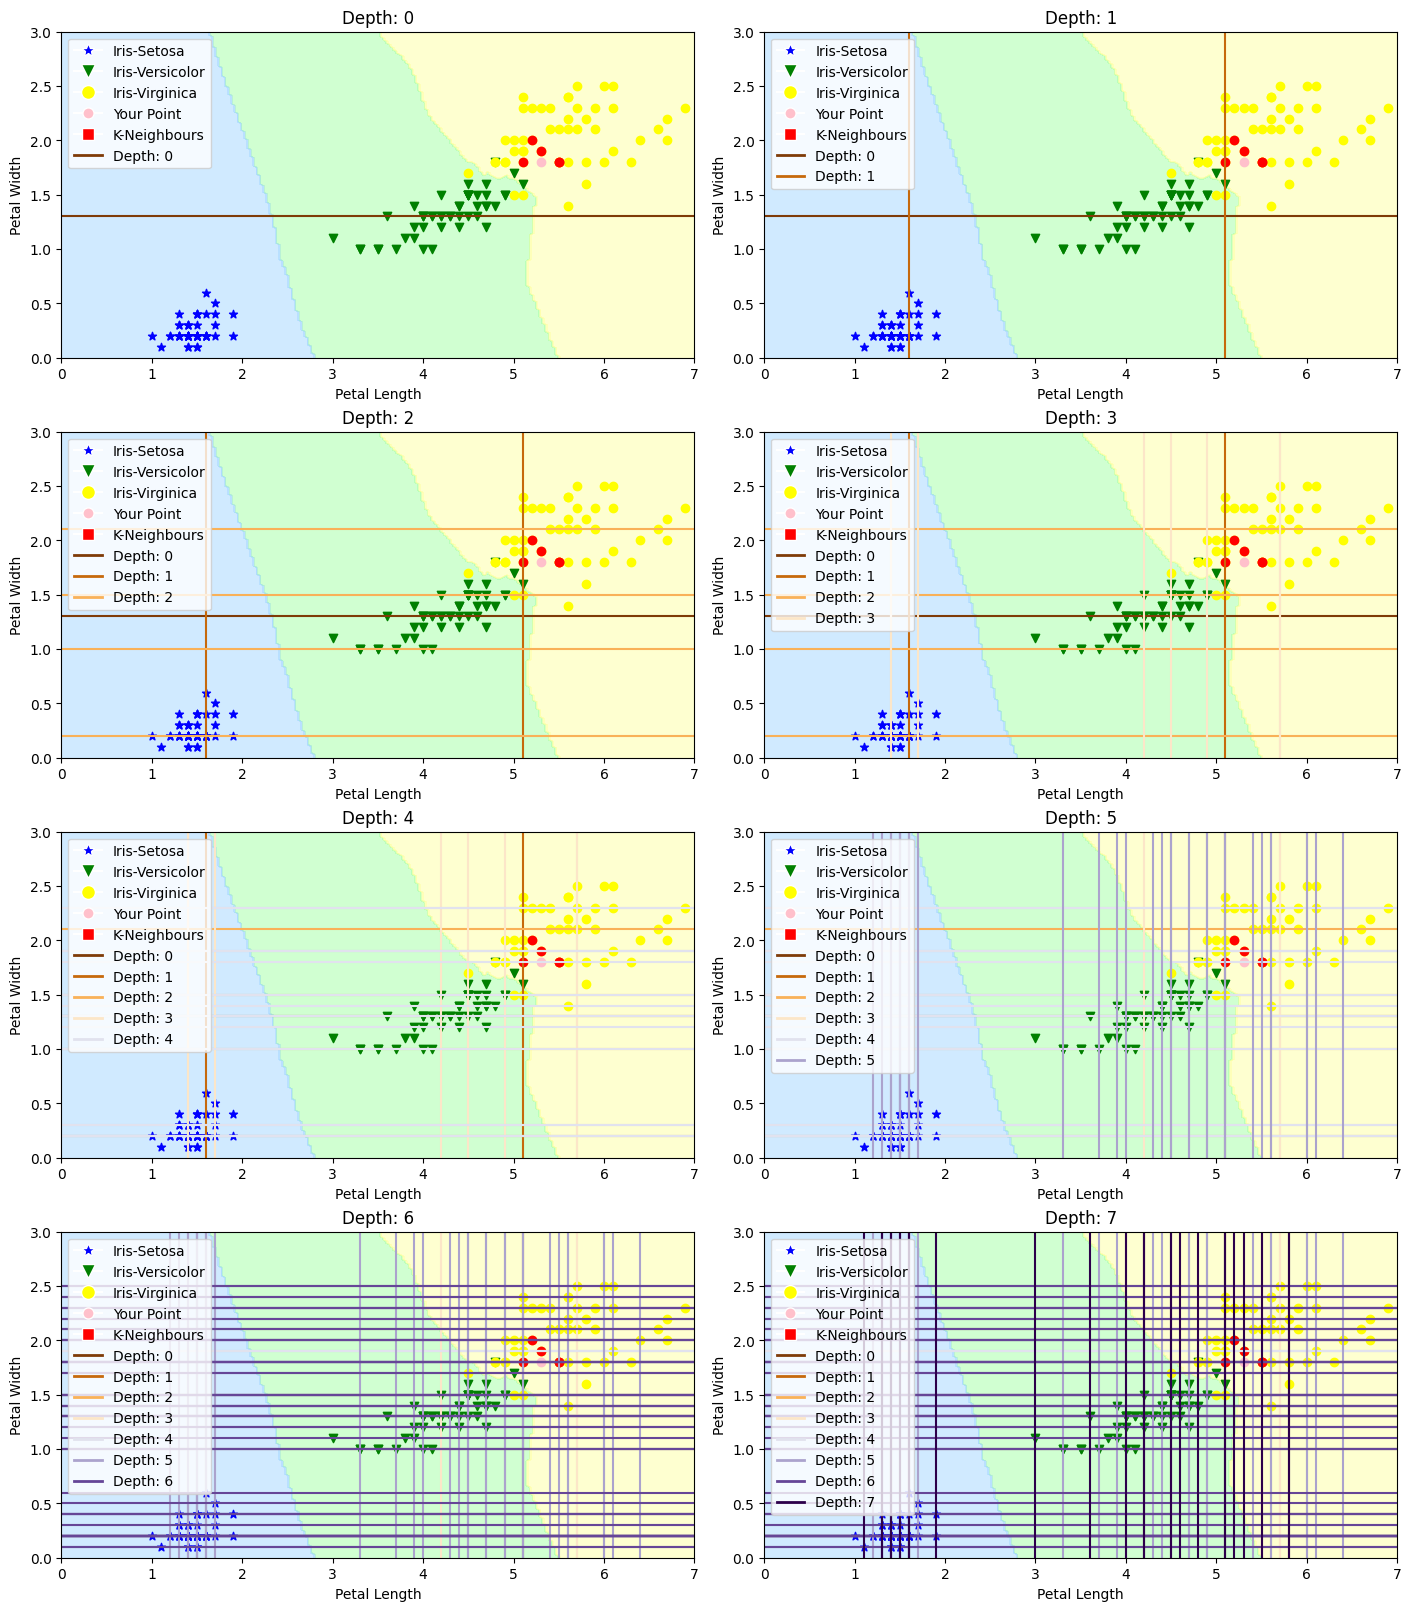

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib import colormaps
from math import ceil

def _normalize(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)

kd_tree_to_plot = kd_tree

vmin = kd_tree_to_plot[list(kd_tree_to_plot.keys())[0]]['depth']
vmax = kd_tree_to_plot[list(kd_tree_to_plot.keys())[-1]]['depth']

query_point = np.array([5.3, 1.8])

X = np.array(X)
k_neighbours = X[k_closest_indexes]

X_setosa = X[:, 1:][y==0]
X_versicolor = X[:, 1:][y==1]
X_virginica = X[:, 1:][y==2]

COLS = 2
rows = ceil(vmax / 2)

fig, axes = plt.subplots(rows, COLS, figsize=(14, 4 * rows), constrained_layout=True)
axes = axes.flatten()

for i in range((vmax + 1), len(axes)):
    fig.delaxes(axes[i])

x_min, x_max = 0, 7
y_min, y_max = 0, 3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample_id, sample in enumerate(data_points):
    predictions[sample_id], _ = predict_kd_tree_np(built_kd_tree=kd_tree_to_plot,
                                                   query=sample,
                                                   target=y)

predictions = predictions.reshape(xx.shape)

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])
cmap_lines = colormaps['PuOr']

for n_depth in range(vmax + 1):
    axes[n_depth].contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)

    axes[n_depth].axis((0.,7., 0.,3.))
    axes[n_depth].contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
    axes[n_depth].scatter(X_setosa[:,0],
                X_setosa[:,1],
                marker="*",
                c="blue", label="Iris-Setosa")
    axes[n_depth].scatter(X_versicolor[:,0],
                X_versicolor[:,1],
                marker="v",
                c="green",
                label="Iris-Versicolor")
    axes[n_depth].scatter(X_virginica[:,0],
                X_virginica[:,1],
                marker="o",
                c="yellow",
                label="Iris-Virginica")

    label_to_marker = {
        0: "*",
        1: "v",
        2: "o",
    }

    axes[n_depth].scatter(query_point[0],
                          query_point[1],
                          marker=label_to_marker[predicted_class],
                          c="pink",
                          label="Your Point")

    for neighbour_idx, neighbour in enumerate(k_neighbours):
        marker = label_to_marker[y[k_closest_indexes][neighbour_idx]]
        axes[n_depth].scatter(
            neighbour[1],
            neighbour[2],
            marker=marker,
            c="red"
        )

    for _, node in kd_tree_to_plot.items():
        if node['depth'] <= n_depth:
            if node['dimension'] == 0:
                axes[n_depth].axvline(x=node['split_value'],
                                      color=cmap_lines(_normalize(
                                          value=node['depth'],
                                          value_min=vmin,
                                          value_max=vmax
                                        )))
            if node['dimension'] == 1:
                axes[n_depth].axhline(y=node['split_value'],
                                      color=cmap_lines(_normalize(
                                          value=node['depth'],
                                          value_min=vmin,
                                          value_max=vmax
                                        )))

    class_handles = [
        Line2D(
            [0], [0],
            marker="*",
            color="w",
            markerfacecolor="blue",
            markersize=10,
            label="Iris-Setosa"),
        Line2D(
            [0], [0],
            marker="v",
            color="w",
            markerfacecolor="green",
            markersize=10,
            label="Iris-Versicolor"),
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="yellow",
            markersize=10,
            label="Iris-Virginica"),
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="pink",
            markersize=8,
            label="Your Point"),
        Line2D(
            [0], [0],
            marker='s',
            color='w',
            markerfacecolor='red',
            markersize=8,
            label='K-Neighbours',
        )
    ]

    depth_handles = [
        Line2D(
            [0], [0],
            color=cmap_lines(_normalize(depth, vmin, vmax)),
            lw=2,
            label=f"Depth: {depth}"
        )
        for depth in range(n_depth + 1)
    ]

    axes[n_depth].legend(handles=class_handles + depth_handles, loc=2)

    axes[n_depth].set_xlabel("Petal Length")
    axes[n_depth].set_ylabel("Petal Width")

    axes[n_depth].set_title(f"Depth: {n_depth}")

plt.show()


## Which is best? <a id="which-is-best"></a>

Each KNN algorithm has its own place. As previously explained, brute-force is often used in scenarios where the number of data points is small and speed is not a priority. When compared to the other tree methods, the brute-force is faster for small datasets and does not require memory to run (only needs the dataset points to infer and never saves or fits a model). The tree based methods, however, require the storage of the fitted tree structure, but, on average, is faster then the brute-force and, in the worst case scenario, it is as fast as this algorithm.

To avoid these scenarios, the tree-based algorithm should be chose according to our dataset characteristics. The Ball Tree works best when the data is clustered or with a higher dimensionality because of the tree structure that looks to group similar data points together. In the other hand, the KD-Tree is faster in low dimensionality data and faster to build, performing best in uniform data distributions, rather than clustering. If you need a rule of thumb, use KD-Tree when there are less than 20 dimensions and your data is not very clustered. Otherwise, pick the Ball Tree, especially when performance is weak in the first option. `scikit-learn` provides an `auto` option for the `algorithm` option that picks the most suitable model for your data. 

# Radius Nearest Neighbours <a id="radius-nearest-neighbours"></a>

Radius Nearest Neighbours is another neighbour-based ML algorithm. This means that the classification of your query point is done based on the class of its neighbours, like in KNN. The intuition in this approach is very similar to KNN, but has some interesting characteristics.

In KNN, the K points that are closest to the query point are identified and, via majority vote, its class is defined. Meanwhile, in Radius Nearest Neighbours instead of considering the K closest points, all the points that are at a distance smaller than the radius are considered in majority voting. This is very simple and most of the principles seen above in KNN are also applied to this algorithm. For example, because we need to calculate the distance to other points, we have to select a distance that will serve as comparison. Again, there are multiple distances to select from (see [distances.ipynb](./metrics/distances.ipynb)), but by default, the Euclidean distance is picked. The distance to the points may also be useful to assess vote importance (for example, closest points could be more important for classification then points that are located further away) and, for that reason, it is normal to couple each neighbour point class to its respective weight.

One problem that arises from this approach that did not happen with KNN is the empty neighbourhoods. If the distance between your query point and the closest point is larger than the selected radius, then no neighbour is considered and no vote is counted. To mitigate this problem, a default class for outliers (which are defined, in this case, as points whose distance to the closest neighbour is larger than the selected radius) is indicated.

Another problem that is more proheminent in this algorithm than it is in KNN (where it also is important), is the scaling of its features. In Nearest Neighbours algorithms, the features that have smaller scales generally contribute more to the voting then the features that range more values. Nevertheless, this generalization is subject to other considerations regarding feature distribution.

Radius Nearest Neighbours has its drawbacks and advantages when compared to KNN. The key difference between these algorithms is that Radius Nearest Neighbours attributes a largest value to the data density. While KNN considers only a limited set of votes, disregarding all of those that are beyond the distance between the query point and the K-th closest points, Radius Nearest Neighbours considers all the points that are located at a distance smaller than the radius. As a subproduct, the Radius Nearest Neighbours includes the data density characteristics in the classification, providing a more honest reflection of the data's geometry.

In the following code cells, you will find the Radius Nearest Neighbours implementation for different distances and search algorithms implementations. This will be heavily inspired in the implementations seen in KNN, with the justified adjustments.

## Brute-force <a id="brute-force-rnn"></a>

To better illustrate the outlier points, the `None` value was attributed, as class, to each point's class. You can experiment with different `r` values to better understand the impact it has on the classification of points!

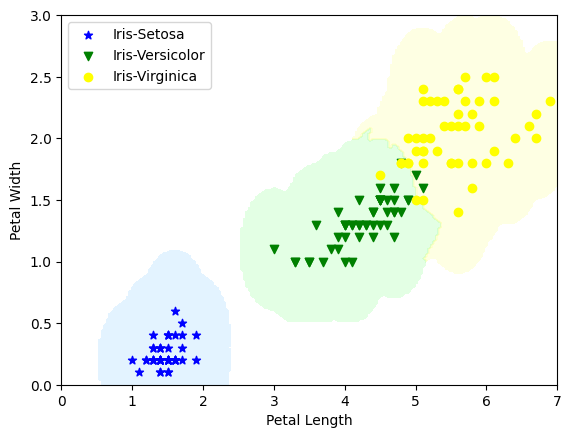

In [1]:
from typing import cast, Dict
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

iris = cast(Dict, datasets.load_iris())
radius = 0.5
X = iris["data"][:, 2:]
y = iris["target"]

# Euclidean distance
def euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two given points."""
    current_sum = 0
    for coord in range(X.shape[1]):
        current_sum += (point1[coord] - point2[coord]) ** 2
    return current_sum ** ( 1 / 2 )

def predict_radius_nn(x_train, y_train, point, r):
    """Predicts a given point class based on the 
    number of votes from points at a distance smaller
    than the radius."""
    votes = []
    for idx, train_point in enumerate(x_train):
        ed = euclidean_distance(point, train_point)
        if ed <= r:
            votes.append(y_train[idx])

    if len(votes) == 0:
        return None

    # Count the total number of votes per class in
    # these K points
    total_votes = np.zeros(len(np.unique(y_train)))
    for vote in votes:
        total_votes[vote] += 1
    # Prediction is the class with the largest amount
    # of votes (in a tie scenario, picks the one with
    # lowest index)
    return int(np.argmax(total_votes))

x_min, x_max = 0, 7
y_min, y_max = 0, 3

# Creates a dataset with every point in the plot, to
# show the predicted class in each set of coordinates
# and plots it
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample in range(data_points.shape[0]):
    predictions[sample] = predict_radius_nn(x_train=X,
                                            y_train=y,
                                            point=data_points[sample, :],
                                            r=radius)

predictions = predictions.reshape(xx.shape)

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend(loc=2)
plt.show()


### Distances impact <a id="distances-impact-rnn"></a>

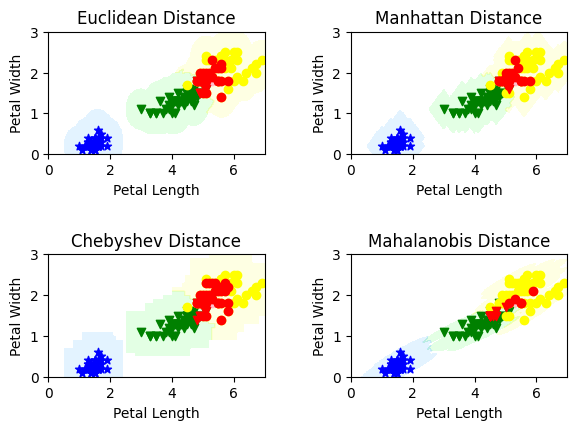

In [2]:
from typing import cast, Dict
from sklearn import datasets
from sklearn.metrics import DistanceMetric
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from math import ceil

your_point = [5.3, 1.8] # your point with coordinates [x,y]

iris = cast(Dict, datasets.load_iris())
X = iris["data"][:, 2:]
y = iris["target"]

radius = 0.5

distances = {
    "euclidean": DistanceMetric.get_metric('euclidean'),
    "manhattan": DistanceMetric.get_metric('manhattan'),
    "chebyshev": DistanceMetric.get_metric('chebyshev'),
    "mahalanobis": DistanceMetric
}

def get_dist_from_list(dist_name, v_mat: np.ndarray | None) -> DistanceMetric:
    """Gets the corresponding DistanceMetric object for a given
    distance name."""
    if dist_name == 'mahalanobis' and v_mat is not None:
        return DistanceMetric.get_metric('mahalanobis', V=v_mat)
    return distances[dist_name]

def calc_any_dist(dist_name, point1, point2, v_mat):
    """Calculates the selected distance between two given points.
    In case the calculated distance is Mahalanobis, requires the
    `v` covariance matrix, obtained from `x`."""
    dist_fun = get_dist_from_list(dist_name, v_mat)
    dist_scalar = dist_fun.pairwise(np.array([point1]),
                                    np.array([point2]))
    return dist_scalar

def predict_radius_nn_dists(x_train, y_train, point, dist_name, r):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    votes = []
    # rowvar=False indicates that the variables are represented in the
    # columns rather than the rows
    v = np.cov(x_train, rowvar=False)
    for idx, train_point in enumerate(x_train):
        dist = calc_any_dist(dist_name, point, train_point, v)
        if dist <= r:
            votes.append((y_train[idx], train_point))

    total_votes = np.zeros(len(np.unique(y_train)))
    for vote in votes:
        total_votes[vote[0]] += 1

    if len(votes) == 0:
        return None, None

    return np.argmax(total_votes), votes

x_min, x_max = 0, 7
y_min, y_max = 0, 3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

rows = 2
cols = ceil(len(distances.keys()) / 2)
fig, axes = plt.subplots(rows, cols)
axes = axes.flatten()

for index, distance_name in enumerate(distances):
    predictions = np.zeros(data_points.shape[0])
    for sample in range(data_points.shape[0]):
        predictions[sample], _ = predict_radius_nn_dists(x_train=X,
                                               y_train=y,
                                               point=data_points[sample, :],
                                               dist_name=distance_name,
                                               r=radius)

    predictions = predictions.reshape(xx.shape)

    your_point_class, neighbours = predict_radius_nn_dists(X,
                                                           y,
                                                           point=your_point,
                                                           dist_name=distance_name,
                                                           r=radius)

    if your_point_class is None or neighbours is None:
        your_point_class = None
        neighbours = []
    else:
        your_point_class = int(your_point_class)

    X_setosa = X[y==0]
    X_versicolor = X[y==1]
    X_virginica = X[y==2]

    cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

    axes[index].axis((0.,7., 0.,3.))
    axes[index].contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
    axes[index].scatter(X_setosa[:,0],
                X_setosa[:,1],
                marker="*",
                c="blue", label="Iris-Setosa")
    axes[index].scatter(X_versicolor[:,0],
                X_versicolor[:,1],
                marker="v",
                c="green",
                label="Iris-Versicolor")
    axes[index].scatter(X_virginica[:,0],
                X_virginica[:,1],
                marker="o",
                c="yellow",
                label="Iris-Virginica")

    label_to_marker = {
        0: "*",
        1: "v",
        2: "o",
    }

    if your_point_class is not None:
        axes[index].scatter(your_point[0],
                    your_point[1],
                    marker=label_to_marker[your_point_class],
                    c="pink",
                    label="Your Point")
    else:
        axes[index].scatter(your_point[0],
                    your_point[1],
                    c="pink",
                    label="Your Point")

    for neighbour_idx, neighbour_info in enumerate(neighbours):
        neighbours_class, neighbours_coordinates = neighbour_info
        marker = label_to_marker[neighbours_class]
        axes[index].scatter(
            neighbours_coordinates[0],
            neighbours_coordinates[1],
            marker=marker,
            c="red"
        )

    axes[index].set_xlabel("Petal Length")
    axes[index].set_ylabel("Petal Width")

    axes[index].set_title(f"{distance_name.capitalize()} Distance")

plt.tight_layout(pad=2.5)
plt.show()


## Ball Tree <a id="ball-tree-rnn"></a>

The Ball Tree algorithm adapts from the KNN algorithm by replacing the heap of K closest points with a list of points that are at a distance smaller than the radius. Similarly, the branch skipping is done in comparison to the radius, not the K-th best distance like in KNN.

############################################################
Hyper-Sphere ID: 00
Hyper-Sphere Depth: 0
Hyper-Sphere Node: 0
Hyper-Sphere Center: (3.95, 1.25)
Hyper-Sphere Radius: 3.13
Hyper-Sphere Children: ['10', '11']


############################################################
Hyper-Sphere ID: 10
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 0
Hyper-Sphere Center: (5.65, 1.75)
Hyper-Sphere Radius: 1.37
Hyper-Sphere Children: ['20', '21']


############################################################
Hyper-Sphere ID: 11
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 1
Hyper-Sphere Center: (2.65, 0.75)
Hyper-Sphere Radius: 1.74
Hyper-Sphere Children: ['22', '23']


############################################################
Hyper-Sphere ID: 20
Hyper-Sphere Depth: 2
Hyper-Sphere Node: 0
Hyper-Sphere Center: (4.70, 1.60)
Hyper-Sphere Radius: 0.50
Hyper-Sphere Children: ['30', '31']


############################################################
Hyper-Sphere ID: 21
Hyper-Sphere Depth: 2
Hyper-Sph

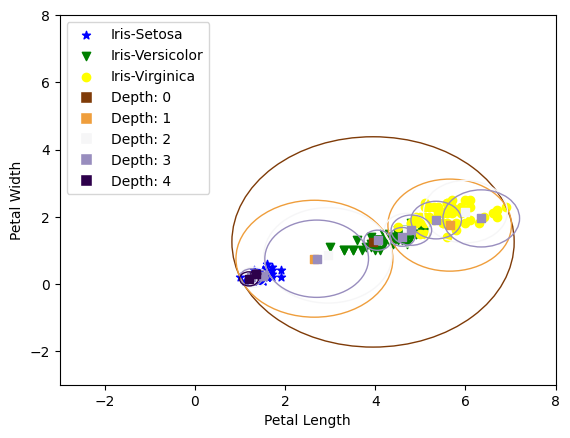

In [1]:
import numpy as np
from typing import cast, Dict
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

random_state = 8
n_leaves = 20

rng = np.random.default_rng(random_state)

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(np.float32)
y = iris['target']

index_col = np.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = np.hstack((index_col, X))

def normalize_rnn(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)

all_leaves_small = False
depth = 0
splits: list[np.ndarray] = [X]
trees: dict[int, list] = {}
new_splits: list[np.ndarray] = []

while True:
    trees[depth] = []
    new_splits = []
    depth_node_counter = 0

    for split in splits:
        split_points = split[:, 1:]

        split_points = np.atleast_2d(split_points)
        pivot = split_points[rng.integers(len(split_points))]

        diff1 = split_points - pivot
        dist1 = np.einsum('ij,ij->i', diff1, diff1)
        furthest = split_points[np.argmax(dist1)]

        diff2 = split_points - furthest
        dist2 = np.einsum('ij,ij->i', diff2, diff2)
        idx2 = np.argmax(dist2)
        opposite = split_points[idx2]
        center = (furthest + opposite) * 0.5

        diff_center = split_points - center
        diff_center = np.einsum('ij,ij->i', diff_center, diff_center)
        radius = float(np.sqrt(np.max(diff_center)))

        split_indexes = None

        if len(split) > n_leaves:
            u = furthest - opposite
            unit_vector = u / np.linalg.norm(u)

            projections = (split_points - furthest) @ unit_vector
            median_val = np.median(projections)
            mask = projections <= median_val
            first_split = split[mask]
            second_split = split[~mask]

            if len(first_split) > 0:
                new_splits.append(first_split)
            if len(second_split) > 0:
                new_splits.append(second_split)

            if len(first_split) > 0 and len(second_split) > 0:
                childs = [
                    str(depth + 1) + str(depth_node_counter),
                    str(depth + 1) + str(depth_node_counter + 1)
                ]
                depth_node_counter += 2
            else:
                childs = None
                split_indexes = split[:, 0]
        else:
            childs = None
            split_indexes = split[:, 0]

        trees[depth].append([center, round(radius, 2), childs, split_indexes])

    if not new_splits:
        break

    if all(len(s) < n_leaves for s in new_splits):
        splits = new_splits
        depth += 1
        continue

    splits = new_splits
    depth += 1


cmap = colormaps['PuOr']
vmin = min(trees.keys())
vmax = max(trees.keys())

x_min, x_max = 0, 7
y_min, y_max = 0, 7

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

X_points = X[:, 1:]

X_setosa = X_points[y==0]
X_versicolor = X_points[y==1]
X_virginica = X_points[y==2]

fig, axes = plt.subplots()


plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

for depth, nodes in trees.items():
    color = cmap(normalize_rnn(depth, vmin, vmax))
    for node_id, node in enumerate(nodes):
        center_point, radius, children, split_indexes = node
        circle = Circle(tuple(center_point), radius, fill=False, color=color)
        axes.add_artist(circle)
        plt.scatter(center_point[0], center_point[1], marker="s", color=color, label="Center")

        print("#" * 60)
        print(f"Hyper-Sphere ID: {depth}{node_id}")
        print(f"Hyper-Sphere Depth: {depth}")
        print(f"Hyper-Sphere Node: {node_id}")
        print(f"Hyper-Sphere Center: ({center_point[0]:.2f}, {center_point[1]:.2f})")
        print(f"Hyper-Sphere Radius: {radius:.2f}")
        if children:
            print(f"Hyper-Sphere Children: {children}")
        if split_indexes is not None:
            print(f"Hyper-Sphere Number of Points: {len(split_indexes)}")
        print("\n")

    depth_legend = Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=f'Depth: {depth}'
    )
    handles.append(depth_legend)
    labels.append(f"Depth: {depth}")

plt.legend(handles, labels, loc=2)
plt.show()


In [2]:
import numpy as np
from typing import cast, Dict
from sklearn.datasets import load_iris

# Loading the same point we did previously
query_point = [5.3, 1.8]

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(np.float32)
y = iris['target']

index_col = np.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = np.hstack((index_col, X))

# Selecting a tree to work with
tree = trees
queue = [['00', None]]
radius = 0.5

def get_euclidean_distance__(point1, point2):
    """Calculates the Euclidean distance between two points"""
    return np.sqrt(np.sum((point1 - point2) ** 2, axis=0))

def get_radius_neighbours(r, points_within_rad, leaves, query, labels_match):
    """Updates the list of the neighbour points"""
    for idx, leave in enumerate(leaves):
        dist = get_euclidean_distance__(query, leave)

        if dist < r:
            points_within_rad.append([leave, labels_match[idx]])
        else:
            points_within_rad.append([leave, None])

    return points_within_rad

def get_child_node_ord(ball_tree, child_nodes, query):
    """Orders the two child nodes based on the best possible distance,
    in ascending order"""
    node_1_center = ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][0]
    node_1_radius = ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][1]
    node_2_center = ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][0]
    node_2_radius = ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][1]

    best_distance_to_node_1 = get_euclidean_distance__(query, node_1_center) - node_1_radius
    best_distance_to_node_2 = get_euclidean_distance__(query, node_2_center) - node_2_radius

    if best_distance_to_node_2 < best_distance_to_node_1:
        return [[child_nodes[1], best_distance_to_node_2],
                [child_nodes[0], best_distance_to_node_1]]
    return [[child_nodes[0], best_distance_to_node_1],
            [child_nodes[1], best_distance_to_node_2]]

neighbours_list = []

while len(queue) > 0:
    node = tree[int(queue[0][0][0])][int(queue[0][0][1])]
    center = node[0]
    ball_r = node[1]

    if not queue[0][1] or int(queue[0][0][0]) == 0:
        queue[0][1] = get_euclidean_distance__(center, query_point) - ball_r

    if queue[0][1] < radius:
        if node[3] is None:
            child_nodes_ordered = get_child_node_ord(tree, node[2], query_point)
            queue = [queue[0]] + child_nodes_ordered + queue[1:]
        else:
            leaves_to_check = X[np.array(node[3], dtype=int)][:, 1:]
            labels = y[np.array(node[3], dtype=int)]
            neighbours_list = get_radius_neighbours(radius,
                                                    neighbours_list,
                                                    leaves_to_check,
                                                    query_point,
                                                    labels)

    queue = queue[1:]

    if not queue:
        break

neighbours_votes = [point[-1] for point in neighbours_list]
votes_counter = np.zeros(len(np.unique(y)))
for vote_ in neighbours_votes:
    votes_counter[vote_] += 1
predicted_class = np.argmax(votes_counter)

print(f"Final Classification: {predicted_class}")


Final Classification: 2


############################################################
Hyper-Sphere ID: 00
Hyper-Sphere Depth: 0
Hyper-Sphere Node: 0
Hyper-Sphere Center: (3.95, 1.25)
Hyper-Sphere Radius: 3.13
Hyper-Sphere Children: ['10', '11']


############################################################
Hyper-Sphere ID: 10
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 0
Hyper-Sphere Center: (5.65, 1.75)
Hyper-Sphere Radius: 1.37
Hyper-Sphere Children: ['20', '21']


############################################################
Hyper-Sphere ID: 11
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 1
Hyper-Sphere Center: (2.65, 0.75)
Hyper-Sphere Radius: 1.74
Hyper-Sphere Children: ['22', '23']


############################################################
Hyper-Sphere ID: 20
Hyper-Sphere Depth: 2
Hyper-Sphere Node: 0
Hyper-Sphere Center: (4.70, 1.60)
Hyper-Sphere Radius: 0.50
Hyper-Sphere Children: ['30', '31']


############################################################
Hyper-Sphere ID: 21
Hyper-Sphere Depth: 2
Hyper-Sph

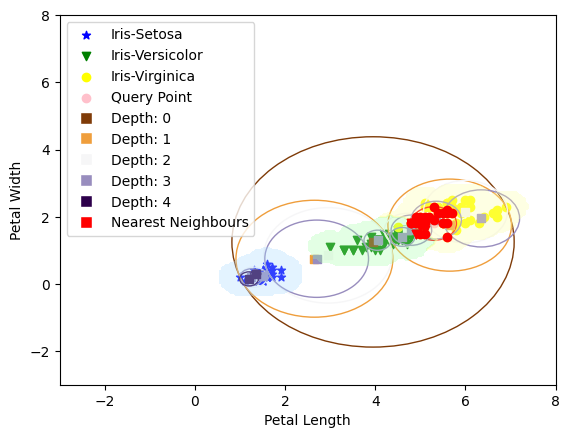

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

def norm__(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)

cmap = colormaps['PuOr']
vmin = min(trees.keys())
vmax = max(trees.keys())

x_min, x_max = -3, 8
y_min, y_max = -3, 8

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])

query_point = [5.3, 1.8]

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(np.float32)
y = iris['target']

index_col = np.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = np.hstack((index_col, X))

X_setosa = X[:, 1:][y==0]
X_versicolor = X[:, 1:][y==1]
X_virginica = X[:, 1:][y==2]

k = 5

def get_euclidean_distance___(point1, point2):
    """Calculates the Euclidean distance between two points"""
    return np.sqrt(np.sum((point1 - point2) ** 2, axis=0))

def get_radius_neighbours_(r, points_within_rad, leaves, query, labels_match):
    """Updates the list of the neighbour points"""
    for idx, leave in enumerate(leaves):
        dist = get_euclidean_distance___(query, leave)

        if dist < r:
            points_within_rad.append([leave, labels_match[idx]])
        else:
            points_within_rad.append([leave, None])

    return points_within_rad

def get_child_node_ord_(ball_tree, child_nodes, query):
    """Orders the two child nodes based on the best possible distance,
    in ascending order"""
    node_1_center = ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][0]
    node_1_radius = ball_tree[int(child_nodes[0][0])][int(child_nodes[0][1])][1]
    node_2_center = ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][0]
    node_2_radius = ball_tree[int(child_nodes[1][0])][int(child_nodes[1][1])][1]

    best_distance_to_node_1 = get_euclidean_distance___(query, node_1_center) - node_1_radius
    best_distance_to_node_2 = get_euclidean_distance___(query, node_2_center) - node_2_radius

    if best_distance_to_node_2 < best_distance_to_node_1:
        return [[child_nodes[1], best_distance_to_node_2],
                [child_nodes[0], best_distance_to_node_1]]
    return [[child_nodes[0], best_distance_to_node_1],
            [child_nodes[1], best_distance_to_node_2]]

def predict_ball_tree_radius(ball_tree, single_query_point, r: float=0.5):
    """Infers the class of a given query point using a built Ball Tree
    for radius neighbours"""
    ball_tree_queue = [['00', None]]
    neighbours_ = []
    while len(ball_tree_queue) > 0:
        tree_node = ball_tree[int(ball_tree_queue[0][0][0])][int(ball_tree_queue[0][0][1])]
        ball_center = tree_node[0]
        ball_radius = tree_node[1]

        if not ball_tree_queue[0][1] or int(ball_tree_queue[0][0][0]) == 0:
            ball_tree_queue[0][1] = get_euclidean_distance___(
                ball_center,
                single_query_point
            ) - ball_radius

        if ball_tree_queue[0][1] < r:
            if tree_node[3] is None:
                ordered_child_nodes = get_child_node_ord_(ball_tree,
                                                          tree_node[2],
                                                          single_query_point)
                ball_tree_queue = [ball_tree_queue[0]] + ordered_child_nodes + ball_tree_queue[1:]
            else:
                leaves_to_check_ = X[np.array(tree_node[3], dtype=int)][:, 1:]
                labels_arr = y[np.array(tree_node[3], dtype=int)]
                neighbours_ = get_radius_neighbours_(r,
                                                    neighbours_,
                                                    leaves_to_check_,
                                                    single_query_point,
                                                    labels_arr)

        ball_tree_queue = ball_tree_queue[1:]

        if not ball_tree_queue:
            break

    votes_counter_ = np.zeros(len(np.unique(y)))
    for vote_counted in neighbours_:
        if vote_counted[-1] is not None:
            votes_counter_[vote_counted[-1]] += 1
    if votes_counter_.sum() == 0:
        return None, neighbours_
    return int(np.argmax(votes_counter_)), neighbours_


for sample in range(data_points.shape[0]):
    predictions[sample], _ = predict_ball_tree_radius(ball_tree=trees,
                                                      single_query_point=data_points[sample])
predictions = predictions.reshape(xx.shape)

your_point_class, neigh_points = predict_ball_tree_radius(ball_tree=trees,
                                                          single_query_point=query_point)

fig, axes = plt.subplots()

plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
if your_point_class is not None:
    plt.scatter(query_point[0],
                query_point[1],
                marker=label_to_marker[int(your_point_class)],
                c="pink",
                label="Query Point")
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

NEIGH_RADIUS = 0.5
neigh_circle = Circle((query_point[0], query_point[1]), NEIGH_RADIUS, fill=False, color='red')
axes.add_artist(neigh_circle)

for depth, nodes in trees.items():
    color = cmap(norm__(depth, vmin, vmax))
    for node_id, node in enumerate(nodes):
        center_point, radius, children, split_indexes = node
        circle = Circle(tuple(center_point), radius, fill=False, color=color)
        axes.add_artist(circle)
        plt.scatter(center_point[0], center_point[1], marker="s", color=color)

        print("#" * 60)
        print(f"Hyper-Sphere ID: {depth}{node_id}")
        print(f"Hyper-Sphere Depth: {depth}")
        print(f"Hyper-Sphere Node: {node_id}")
        print(f"Hyper-Sphere Center: ({center_point[0]:.2f}, {center_point[1]:.2f})")
        print(f"Hyper-Sphere Radius: {radius:.2f}")
        if children:
            print(f"Hyper-Sphere Children: {children}")
        if split_indexes is not None:
            print(f"Hyper-Sphere Number of Points: {len(split_indexes)}")
        print("\n")

    depth_legend = Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=f'Depth: {depth}'
    )
    handles.append(depth_legend)
    labels.append(f"Depth: {depth}")

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)

for neigh_point in neigh_points:
    if neigh_point[-1] is not None:
        marker = label_to_marker[neigh_point[-1]]
        plt.scatter(
            neigh_point[0][0],
            neigh_point[0][1],
            marker=marker,
            c="red"
        )

knn_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='red',
    markersize=8,
    label='Nearest Neighbours'
)

handles.append(knn_legend)
labels.append("Nearest Neighbours")

plt.legend(handles, labels, loc=2)
plt.show()


## KD Tree <a id="kd-tree-knn"></a>

Similar to the changes in the Ball Tree algorithm, the adaptation from KNN to Radius Neighbours is fairly simple. The construction of the tree itself does not change, just the inference: the distances are compared to the radius instead of the furthest K-neighbour.

In [ ]:
# Loading data and initializing variables
import numpy as np
from typing import cast, Dict
from sklearn.datasets import load_iris

random_state = 8
rng = np.random.default_rng(random_state)

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:]
X = np.hstack([np.arange(X.shape[0]).reshape(-1, 1), X])
y = iris['target']

dimension_options = list(range(X.shape[1] - 1))

query_point = np.array([5.3, 1.8])

radius = 0.5

def create_kd_tree_rnn_np(dim_order):
    """Creates an optimal KD Tree"""
    n_dims = len(dim_order)
    nds = {}
    depth_idx = {}
    nds[0] = {
        'node_id': 0,
        'depth': 0,
        'dimension': dim_order[0],
        'points_indexes': np.array(X[:, 0], dtype=int)
    }
    depth_idx[0] = [0]
    d = 0
    node_count = 1
    while d in depth_idx:
        next_dim_iter = (d + 1) % n_dims
        for nd_id in depth_idx[d]:
            nd = nds[nd_id]
            dim = nd['dimension']
            pts = X[nd['points_indexes']]

            median_pos = pts.shape[0] // 2
            order = np.argpartition(pts[:, dim + 1], median_pos)
            pts_sorted = pts[order]

            median_point = pts_sorted[median_pos]
            left_idxs = pts_sorted[:median_pos, 0].astype(int)
            right_idxs = pts_sorted[median_pos + 1:, 0].astype(int)

            nd['median_point'] = median_point
            nd['split_value'] = median_point[dim + 1]
            del nd['points_indexes']

            if pts.shape[0] == 1:
                nd['left_node'] = nd['right_node'] = None
                continue

            if d + 1 not in depth_idx:
                depth_idx[d + 1] = []


            def _add_child(indexes_, next_d):
                nonlocal node_count
                if len(indexes_) == 0:
                    return None
                nid = node_count
                nds[nid] = {
                    'node_id': nid,
                    'depth': d + 1,
                    'dimension': next_d,
                    'points_indexes': indexes_
                }
                depth_idx[d + 1].append(nid)
                node_count += 1
                return nid

            next_dim = dim_order[next_dim_iter]
            nd['left_node'] = _add_child(left_idxs, next_dim)
            nd['right_node'] = _add_child(right_idxs, next_dim)

        d += 1
    return nds


def predict_kd_tree_rnn_np(built_kd_tree, target, query, r):
    """Predicts a class for a given data point, using an already created KD Tree"""
    nds = built_kd_tree
    q = [0]
    neighbours_indexes = []
    r2 = r ** 2

    while q:
        nd = nds[q.pop(0)]
        dim = nd['dimension']
        coord_diff = query[dim] - nd['split_value']

        near_nd = nd['left_node'] if coord_diff < 0 else nd['right_node']
        far_nd = nd['right_node'] if coord_diff < 0 else nd['left_node']

        if near_nd is not None:
            q.insert(0, near_nd)

        if far_nd is not None and coord_diff ** 2 < r2:
            q.insert(0, far_nd)

        diff = query - nd['median_point'][1:]
        d2 = float(np.dot(diff, diff))

        if d2 < r2:
            neighbours_indexes.append(int(nd['median_point'][0]))

    votes = np.bincount(target[neighbours_indexes], minlength=len(np.unique(target)))
    if np.sum(votes) == 0:
        return None, neighbours_indexes
    return int(np.argmax(votes)), neighbours_indexes

dimension_order = rng.permutation(dimension_options)
kd_tree = create_kd_tree_rnn_np(dimension_order)
predicted_class, neighbours_closest_indexes = predict_kd_tree_rnn_np(kd_tree,
                                                                     y,
                                                                     query_point,
                                                                     r=radius)

print(f"Final Classification: {predicted_class}")


Final Classification: 2


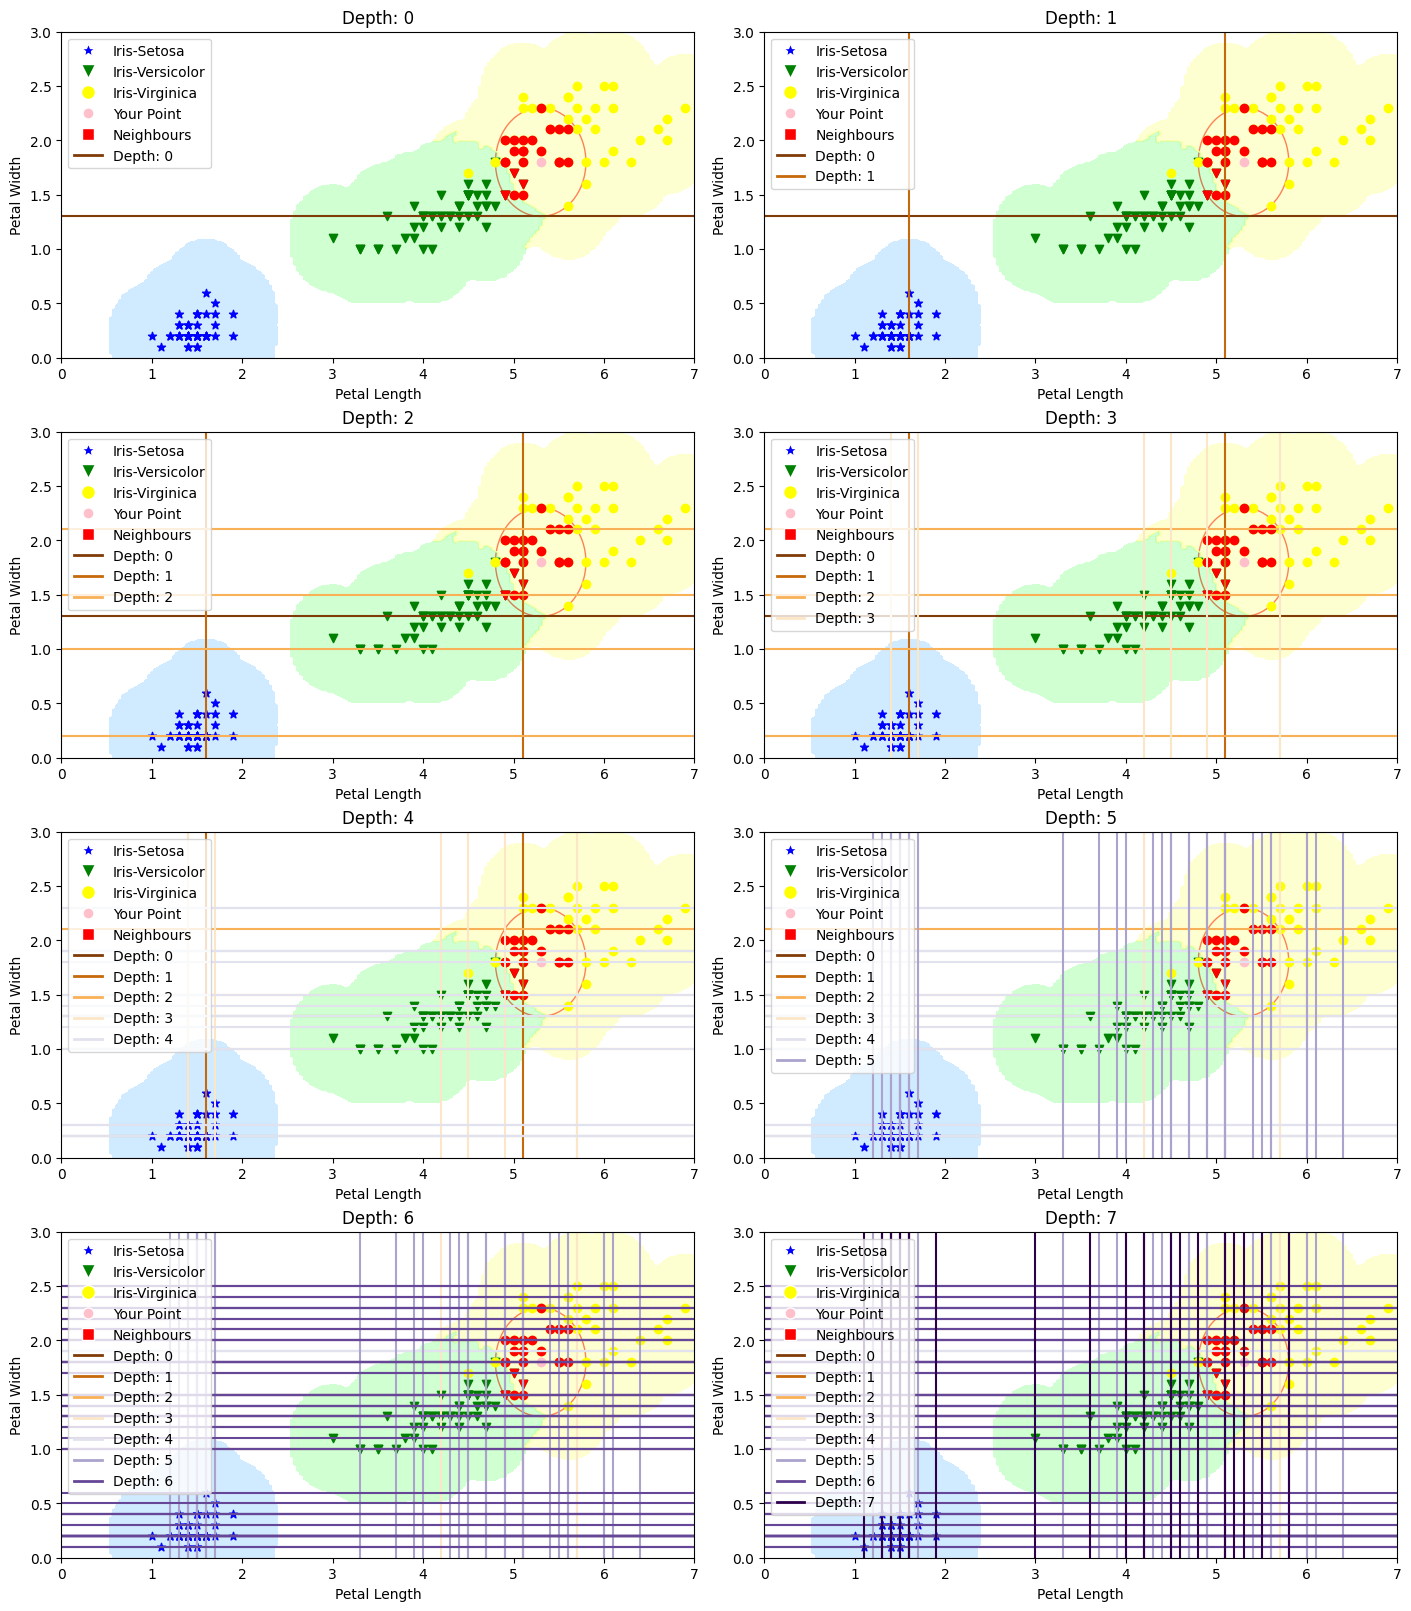

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from matplotlib import colormaps
from math import ceil

def __normalize(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)

kd_tree_to_plot = kd_tree
radius = 0.5

vmin = kd_tree_to_plot[list(kd_tree_to_plot.keys())[0]]['depth']
vmax = kd_tree_to_plot[list(kd_tree_to_plot.keys())[-1]]['depth']

query_point = np.array([5.3, 1.8])

X = np.array(X)
k_neighbours = X[neighbours_closest_indexes]

X_setosa = X[:, 1:][y==0]
X_versicolor = X[:, 1:][y==1]
X_virginica = X[:, 1:][y==2]

cols = 2
rows = ceil(vmax / 2)

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), constrained_layout=True)
axes = axes.flatten()

for i in range((vmax + 1), len(axes)):
    fig.delaxes(axes[i])

x_min, x_max = 0, 7
y_min, y_max = 0, 3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample_id, sample in enumerate(data_points):
    predictions[sample_id], _ = predict_kd_tree_rnn_np(built_kd_tree=kd_tree_to_plot,
                                                       query=sample,
                                                       target=y,
                                                       r=radius)

predictions = predictions.reshape(xx.shape)

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])
cmap_lines = colormaps['PuOr']


for n_depth in range(vmax + 1):
    neigh_circle = Circle((query_point[0], query_point[1]), radius, fill=False, color='red')
    axes[n_depth].add_artist(neigh_circle)
    axes[n_depth].contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)

    axes[n_depth].axis((0.,7., 0.,3.))
    axes[n_depth].contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
    axes[n_depth].scatter(X_setosa[:,0],
                X_setosa[:,1],
                marker="*",
                c="blue", label="Iris-Setosa")
    axes[n_depth].scatter(X_versicolor[:,0],
                X_versicolor[:,1],
                marker="v",
                c="green",
                label="Iris-Versicolor")
    axes[n_depth].scatter(X_virginica[:,0],
                X_virginica[:,1],
                marker="o",
                c="yellow",
                label="Iris-Virginica")

    label_to_marker = {
        0: "*",
        1: "v",
        2: "o",
    }

    if predicted_class is not None:
        axes[n_depth].scatter(query_point[0],
                            query_point[1],
                            marker=label_to_marker[predicted_class],
                            c="pink",
                            label="Your Point")

    for neighbour_idx, neighbour in enumerate(k_neighbours):
        marker = label_to_marker[y[neighbours_closest_indexes][neighbour_idx]]
        axes[n_depth].scatter(
            neighbour[1],
            neighbour[2],
            marker=marker,
            c="red"
        )

    for _, node in kd_tree_to_plot.items():
        if node['depth'] <= n_depth:
            if node['dimension'] == 0:
                axes[n_depth].axvline(x=node['split_value'],
                                      color=cmap_lines(__normalize(
                                          value=node['depth'],
                                          value_min=vmin,
                                          value_max=vmax
                                        )))
            if node['dimension'] == 1:
                axes[n_depth].axhline(y=node['split_value'],
                                      color=cmap_lines(__normalize(
                                          value=node['depth'],
                                          value_min=vmin,
                                          value_max=vmax
                                        )))

    class_handles = [
        Line2D(
            [0], [0],
            marker="*",
            color="w",
            markerfacecolor="blue",
            markersize=10,
            label="Iris-Setosa"),
        Line2D(
            [0], [0],
            marker="v",
            color="w",
            markerfacecolor="green",
            markersize=10,
            label="Iris-Versicolor"),
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="yellow",
            markersize=10,
            label="Iris-Virginica"),
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="pink",
            markersize=8,
            label="Your Point"),
        Line2D(
            [0], [0],
            marker='s',
            color='w',
            markerfacecolor='red',
            markersize=8,
            label='Neighbours',
        )
    ]

    depth_handles = [
        Line2D(
            [0], [0],
            color=cmap_lines(__normalize(depth, vmin, vmax)),
            lw=2,
            label=f"Depth: {depth}"
        )
        for depth in range(n_depth + 1)
    ]

    axes[n_depth].legend(handles=class_handles + depth_handles, loc=2)

    axes[n_depth].set_xlabel("Petal Length")
    axes[n_depth].set_ylabel("Petal Width")

    axes[n_depth].set_title(f"Depth: {n_depth}")

plt.show()
